## Importing dataset and libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/mayan/Documents/projects/FRAUD_TRANSACTION_DETECTION_SYSTEM/datasets/Base.csv')
print(df.head(10))
print("-----------------------------------------------------------------------")
print(df.tail(10))
print("-----------------------------------------------------------------------")
print(df.describe())
print("-----------------------------------------------------------------------")
print(df.info())

   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   
5           0     0.6               0.294840                         -1   
6           0     0.2               0.773085                         22   
7           0     0.8               0.153880                         -1   
8           0     0.3               0.523655                         21   
9           0     0.8               0.834475                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1                            89     

### checking unique values for each column in dataset

In [2]:
for col in df.columns:
    with open("unique_values.txt", "a", encoding="utf-8") as f:
        print(f"column ---------- {col}", file=f)
        print(df[col].unique(), "\n", file=f)

### as we can see there is no other unique values for column device_fraud_count other than zero we can drop the column

In [3]:
df.shape

(1000000, 32)

In [4]:
if 'device_fraud_count' in df.columns:
    print(df.drop(columns=['device_fraud_count'],axis=0,inplace=True))
df.drop_duplicates(inplace=True)

None


In [5]:
df.shape

(1000000, 31)

###  handling the negative columns for each column and checking there correlation with the target column (fraud)

In [6]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        count = (df[col] < 0).sum()
        # print(df[col].size)
        if count > 0:
            print(col, ":", count, ":", (count/df[col].size)*100)

        

prev_address_months_count : 712920 : 71.292
current_address_months_count : 4254 : 0.4254
intended_balcon_amount : 742523 : 74.2523
velocity_6h : 44 : 0.0044
credit_risk_score : 14445 : 1.4445
bank_months_count : 253635 : 25.3635
session_length_in_minutes : 2015 : 0.20149999999999998
device_distinct_emails_8w : 359 : 0.0359


In [7]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
            count1 = (df[col] < 0).sum()
            count2 = ((df[col] < 0) & (df['fraud_bool'] == 1)).sum()
            if(count1 > 0):
                print(col,":",count1,":",count2)
            
            

prev_address_months_count : 712920 : 10134
current_address_months_count : 4254 : 14
intended_balcon_amount : 742523 : 9747
velocity_6h : 44 : 0
credit_risk_score : 14445 : 56
bank_months_count : 253635 : 4140
session_length_in_minutes : 2015 : 18
device_distinct_emails_8w : 359 : 4


In [8]:
### overall fraud rate

((df['fraud_bool'] == 1).sum() / (df['fraud_bool'].size))*100

np.float64(1.1029)

In [9]:
sentinel_cols = [
    'prev_address_months_count',
    'current_address_months_count',
    'bank_months_count',
    'device_distinct_emails_8w'
]

for col in sentinel_cols:

    result = df.groupby(df[col] == -1)['fraud_bool'].agg(
        count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )

    result['fraud_rate'] *= 100

    print(result)

                            count  fraud_count  fraud_rate
prev_address_months_count                                 
False                      287080          895    0.311760
True                       712920        10134    1.421478
                               count  fraud_count  fraud_rate
current_address_months_count                                 
False                         995746        11015    1.106206
True                            4254           14    0.329102
                    count  fraud_count  fraud_rate
bank_months_count                                 
False              746365         6889    0.923007
True               253635         4140    1.632267
                            count  fraud_count  fraud_rate
device_distinct_emails_8w                                 
False                      999641        11025    1.102896
True                          359            4    1.114206


In [10]:
df['prev_address_missing'] = (
    df['prev_address_months_count'] == -1
).astype(int)

df['current_address_missing'] = (
    df['current_address_months_count'] == -1
).astype(int)

df['bank_months_missing'] = (
    df['bank_months_count'] == -1
).astype(int)

df['device_emails_missing'] = (
    df['device_distinct_emails_8w'] == -1
).astype(int)

In [11]:
other_negative_cols = [
    'intended_balcon_amount',
    'velocity_6h',
    'credit_risk_score',
    'session_length_in_minutes'
]

for col in other_negative_cols:

    result = df.groupby(df[col] < 0)['fraud_bool'].agg(
        count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )

    result['fraud_rate'] *= 100

    print(result)

                         count  fraud_count  fraud_rate
intended_balcon_amount                                 
False                   257477         1282    0.497909
True                    742523         9747    1.312687
              count  fraud_count  fraud_rate
velocity_6h                                 
False        999956        11029    1.102949
True             44            0    0.000000
                    count  fraud_count  fraud_rate
credit_risk_score                                 
False              985555        10973    1.113383
True                14445           56    0.387677
                            count  fraud_count  fraud_rate
session_length_in_minutes                                 
False                      997985        11011    1.103323
True                         2015           18    0.893300


## Numerical descriptive statistics  
## Fraud vs legitimate statistics 

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_cols.remove('fraud_bool')

print(numeric_cols)

['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'month', 'prev_address_missing', 'current_address_missing', 'bank_months_missing', 'device_emails_missing']


In [13]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404
velocity_24h,1000000.0,4769.781965,1479.212612,1.300307e+03,3593.179135,4749.921161,5752.574191,9506.896596


In [14]:
stats = df[numeric_cols].describe().T

stats['skewness'] = df[numeric_cols].skew()

print(stats)

                                      count         mean          std  \
income                            1000000.0     0.562696     0.290343   
name_email_similarity             1000000.0     0.493694     0.289125   
prev_address_months_count         1000000.0    16.718568    44.046230   
current_address_months_count      1000000.0    86.587867    88.406599   
customer_age                      1000000.0    33.689080    12.025799   
days_since_request                1000000.0     1.025705     5.381835   
intended_balcon_amount            1000000.0     8.661499    20.236155   
zip_count_4w                      1000000.0  1572.692049  1005.374565   
velocity_6h                       1000000.0  5665.296605  3009.380665   
velocity_24h                      1000000.0  4769.781965  1479.212612   
velocity_4w                       1000000.0  4856.324016   919.843934   
bank_branch_count_8w              1000000.0   184.361849   459.625329   
date_of_birth_distinct_emails_4w  1000000.0     9.5

In [15]:
comparison = df.groupby('fraud_bool')[numeric_cols].agg(
    ['mean', 'median']
)

print(comparison)

              income        name_email_similarity            \
                mean median                  mean    median   
fraud_bool                                                    
0           0.561313    0.6              0.494815  0.493571   
1           0.686635    0.8              0.393161  0.292420   

           prev_address_months_count        current_address_months_count  \
                                mean median                         mean   
fraud_bool                                                                 
0                          16.839647   -1.0                    86.273232   
1                           5.861365   -1.0                   114.801161   

                  customer_age         ...     month         \
           median         mean median  ...      mean median   
fraud_bool                             ...                    
0            52.0    33.609125   30.0  ...  3.285582    3.0   
1            94.0    40.858645   40.0  ...  3.56596

## Numerical Distribution Analysis.

In [16]:
continuous_cols = [
    'income',
    'name_email_similarity',
    'prev_address_months_count',
    'current_address_months_count',
    'customer_age',
    'days_since_request',
    'intended_balcon_amount',
    'zip_count_4w',
    'velocity_6h',
    'velocity_24h',
    'velocity_4w',
    'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w',
    'credit_risk_score',
    'proposed_credit_limit',
    'session_length_in_minutes',
    'device_distinct_emails_8w'
]

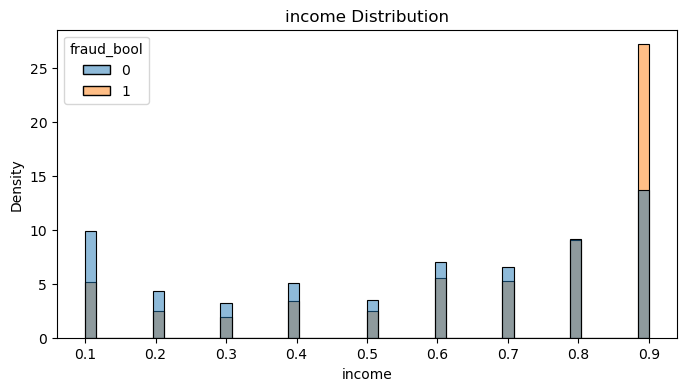

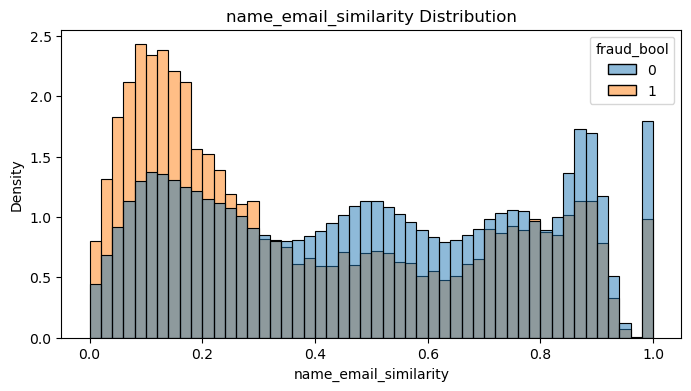

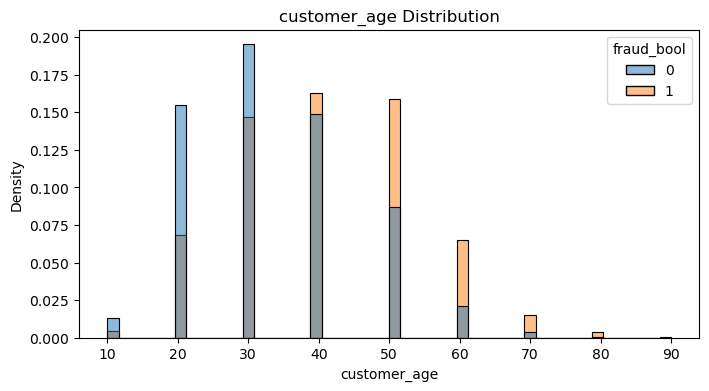

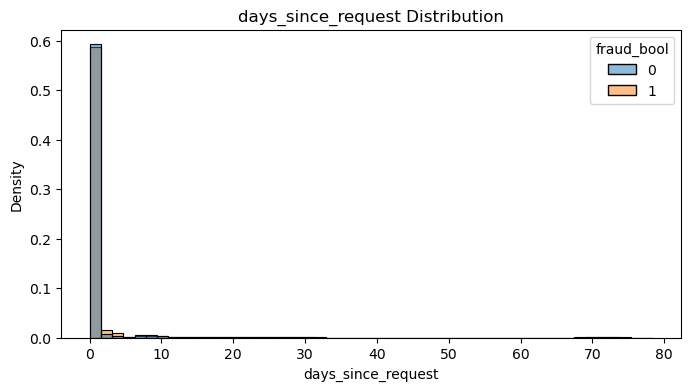

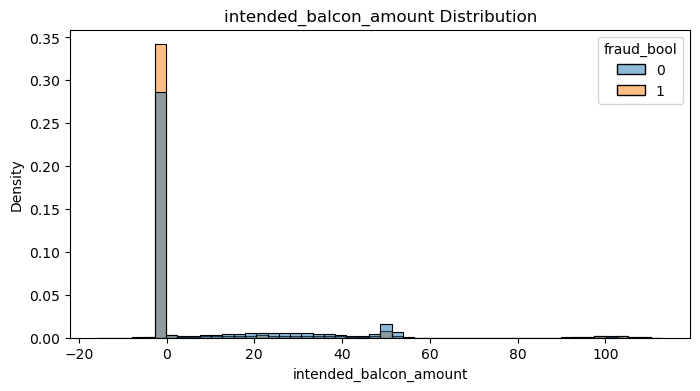

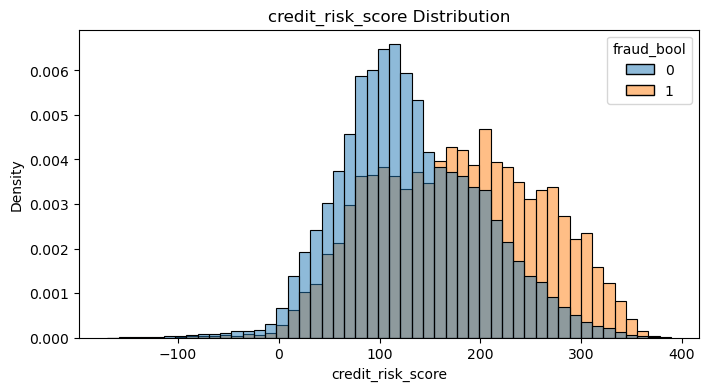

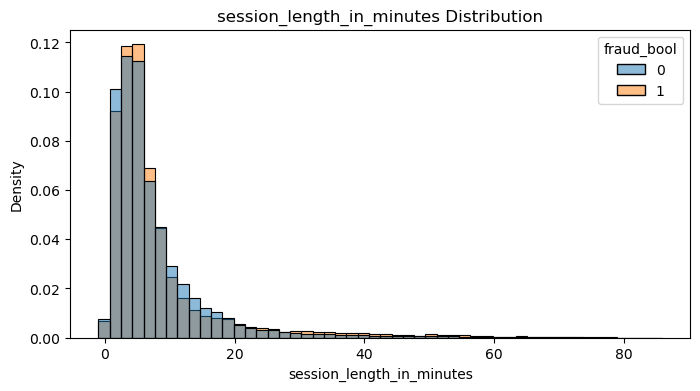

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = [
    'income',
    'name_email_similarity',
    'customer_age',
    'days_since_request',
    'intended_balcon_amount',
    'credit_risk_score',
    'session_length_in_minutes'
]

for col in cols_to_plot:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        hue='fraud_bool',
        bins=50,
        stat='density',
        common_norm=False
    )

    plt.title(f'{col} Distribution')
    plt.show()

In [18]:
income_bin = pd.qcut(
    df['income'],
    q=10,
    duplicates='drop'
)

income_analysis = df.groupby(
    income_bin,
    observed=True
)['fraud_bool'].agg(
    count='count',
    fraud_count='sum',
    fraud_rate='mean'
)

income_analysis['fraud_rate'] *= 100

print(income_analysis)

               count  fraud_count  fraud_rate
income                                       
(0.099, 0.2]  226794         1347    0.593931
(0.2, 0.4]    132197          935    0.707278
(0.4, 0.5]     55858          444    0.794873
(0.5, 0.6]    111973          983    0.877890
(0.6, 0.7]    105109          927    0.881942
(0.7, 0.8]    146650         1602    1.092397
(0.8, 0.9]    221419         4791    2.163771


In [19]:
def fraud_rate_by_quantile(df, col, q=10):

    temp = df[[col, 'fraud_bool']].copy()

    temp['bin'] = pd.qcut(
        temp[col],
        q=q,
        duplicates='drop'
    )

    result = temp.groupby(
        'bin',
        observed=True
    )['fraud_bool'].agg(
        count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )

    result['fraud_rate'] *= 100

    return result

In [20]:
fraud_rate_by_quantile(df, 'income')

,count,fraud_count,fraud_rate
bin,,,
"(0.099, 0.2]",226794,1347,0.593931
"(0.2, 0.4]",132197,935,0.707278
"(0.4, 0.5]",55858,444,0.794873
"(0.5, 0.6]",111973,983,0.877890
"(0.6, 0.7]",105109,927,0.881942
"(0.7, 0.8]",146650,1602,1.092397
"(0.8, 0.9]",221419,4791,2.163771


In [21]:
fraud_rate_by_quantile(df, 'credit_risk_score')

,count,fraud_count,fraud_rate
bin,,,
"(-170.001, 48.0]",101543,553,0.544597
"(48.0, 73.0]",98852,673,0.680816
"(73.0, 92.0]",104773,741,0.707243
"(92.0, 107.0]",96088,609,0.633794
"(107.0, 122.0]",99356,610,0.613954
"(122.0, 141.0]",103698,716,0.690467
"(141.0, 165.0]",98370,1000,1.016570
"(165.0, 192.0]",100084,1255,1.253947
"(192.0, 226.0]",98672,1539,1.559713


In [22]:
fraud_rate_by_quantile(df, 'name_email_similarity')

,count,fraud_count,fraud_rate
bin,,,
"(-0.00099857, 0.107]",100000,2050,2.050
"(0.107, 0.183]",100000,1862,1.862
"(0.183, 0.272]",100000,1350,1.350
"(0.272, 0.39]",100000,1089,1.089
"(0.39, 0.492]",100000,708,0.708
"(0.492, 0.588]",100000,695,0.695
"(0.588, 0.707]",100000,753,0.753
"(0.707, 0.806]",100000,999,0.999
"(0.806, 0.883]",100000,835,0.835


In [23]:
fraud_rate_by_quantile(df, 'intended_balcon_amount')

,count,fraud_count,fraud_rate
bin,,,
"(-15.532, -1.446]",100000,1034,1.034
"(-1.446, -1.258]",100000,1212,1.212
"(-1.258, -1.109]",100000,1305,1.305
"(-1.109, -0.972]",100000,1300,1.300
"(-0.972, -0.831]",100000,1289,1.289
"(-0.831, -0.665]",100000,1481,1.481
"(-0.665, -0.408]",100000,1482,1.482
"(-0.408, 19.102]",100000,890,0.890
"(19.102, 39.763]",100000,486,0.486


In [24]:
fraud_rate_by_quantile(df, 'customer_age')

,count,fraud_count,fraud_rate
bin,,,
"(9.999, 20.0]",266842,1279,0.479310
"(20.0, 30.0]",311433,2589,0.831318
"(30.0, 40.0]",238712,2876,1.204799
"(40.0, 50.0]",140353,2805,1.998532
"(50.0, 90.0]",42660,1480,3.469292


In [25]:
features_to_analyze = [
    'income',
    'customer_age',
    'credit_risk_score',
    'intended_balcon_amount'
]

for col in features_to_analyze:
    print(f"\n{'='*60}")
    print(col)
    print('='*60)
    print(fraud_rate_by_quantile(df, col))


income
               count  fraud_count  fraud_rate
bin                                          
(0.099, 0.2]  226794         1347    0.593931
(0.2, 0.4]    132197          935    0.707278
(0.4, 0.5]     55858          444    0.794873
(0.5, 0.6]    111973          983    0.877890
(0.6, 0.7]    105109          927    0.881942
(0.7, 0.8]    146650         1602    1.092397
(0.8, 0.9]    221419         4791    2.163771

customer_age
                count  fraud_count  fraud_rate
bin                                           
(9.999, 20.0]  266842         1279    0.479310
(20.0, 30.0]   311433         2589    0.831318
(30.0, 40.0]   238712         2876    1.204799
(40.0, 50.0]   140353         2805    1.998532
(50.0, 90.0]    42660         1480    3.469292

credit_risk_score
                   count  fraud_count  fraud_rate
bin                                              
(-170.001, 48.0]  101543          553    0.544597
(48.0, 73.0]       98852          673    0.680816
(73.0, 92.0]    

In [26]:
features_to_analyze = [
    'days_since_request',
    'velocity_6h',
    'velocity_24h',
    'velocity_4w',
    'session_length_in_minutes'
]

for col in features_to_analyze:
    print(f"\n{'='*60}")
    print(col)
    print('='*60)
    print(fraud_rate_by_quantile(df, col))


days_since_request
                                    count  fraud_count  fraud_rate
bin                                                               
(-0.0009999959600000001, 0.00285]  100000         1358       1.358
(0.00285, 0.00572]                 100000         1320       1.320
(0.00572, 0.00869]                 100000         1228       1.228
(0.00869, 0.0118]                  100000         1135       1.135
(0.0118, 0.0152]                   100000         1191       1.191
(0.0152, 0.019]                    100000         1096       1.096
(0.019, 0.0235]                    100000          984       0.984
(0.0235, 0.0298]                   100000          848       0.848
(0.0298, 0.0476]                   100000          621       0.621
(0.0476, 78.457]                   100000         1248       1.248

velocity_6h
                        count  fraud_count  fraud_rate
bin                                                   
(-170.604, 1828.024]   100000         1456       1.45

In [27]:
categorical_cols = [
    'payment_type',
    'employment_status',
    'housing_status',
    'source',
    'device_os'
]

overall_fraud_rate = df['fraud_bool'].mean() * 100

for col in categorical_cols:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    result = df.groupby(col)['fraud_bool'].agg(
        count='count',
        fraud_count='sum',
        fraud_rate='mean'
    )

    result['fraud_rate'] *= 100
    result['difference_from_overall'] = (
        result['fraud_rate'] - overall_fraud_rate
    )

    print(result.sort_values('fraud_rate', ascending=False))


payment_type
               count  fraud_count  fraud_rate  difference_from_overall
payment_type                                                          
AC            252071         4209    1.669768                 0.566868
AB            370554         4169    1.125072                 0.022172
AD            118837         1286    1.082155                -0.020745
AA            258249         1364    0.528172                -0.574728
AE               289            1    0.346021                -0.756879

employment_status
                    count  fraud_count  fraud_rate  difference_from_overall
employment_status                                                          
CC                  37758          932    2.468351                 1.365451
CG                    453            7    1.545254                 0.442354
CA                 730252         8899    1.218620                 0.115720
CB                 138288          953    0.689142                -0.413758
CD            

In [28]:
corr = df.select_dtypes(include=np.number).corr()['fraud_bool'] \
         .sort_values(ascending=False)

print(corr)

fraud_bool                          1.000000
credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
prev_address_missing                0.048070
income                              0.045079
device_distinct_emails_8w           0.035704
current_address_months_count        0.033701
bank_months_missing                 0.029548
email_is_free                       0.027758
foreign_request                     0.016885
month                               0.013250
session_length_in_minutes           0.008999
zip_count_4w                        0.005212
days_since_request                  0.000567
device_emails_missing               0.000021
bank_months_count                  -0.003222
current_address_missing            -0.004843
velocity_24h                       -0.011183
velocity_4w                        -0.011536
bank_branch_count_8w               -0.011577
phone_mobile_valid                 -0.013180
velocity_6

In [29]:
month_analysis = df.groupby('month')['fraud_bool'].agg(
    count='count',
    fraud_count='sum',
    fraud_rate='mean'
)

month_analysis['fraud_rate'] *= 100

print(month_analysis)

        count  fraud_count  fraud_rate
month                                 
0      132440         1500    1.132588
1      127620         1198    0.938724
2      136979         1198    0.874587
3      150936         1392    0.922245
4      127691         1452    1.137120
5      119323         1411    1.182505
6      108168         1450    1.340507
7       96843         1428    1.474552


![Fraud rate by month.png](<attachment:Fraud rate by month.png>)
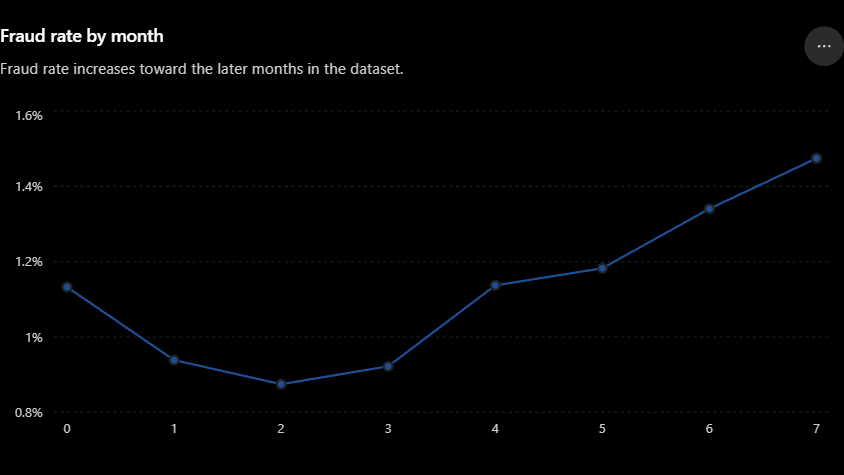

# PHASE 2 - Feature Engineering

Train / Validation / Test Split

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [32]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nFraud rates:")
print("Train:", y_train.mean() * 100)
print("Validation:", y_val.mean() * 100)
print("Test:", y_test.mean() * 100)

Train: (700000, 34) (700000,)
Validation: (150000, 34) (150000,)
Test: (150000, 34) (150000,)

Fraud rates:
Train: 1.102857142857143
Validation: 1.1033333333333333
Test: 1.1026666666666667


### ------------------------ HANDLING SENTINEL VALUES ------------------------

In [33]:
old_missing_cols = [
    'prev_address_missing',
    'current_address_missing',
    'bank_months_missing',
    'device_emails_missing'
]

X_train = X_train.drop(columns=old_missing_cols, errors='ignore')
X_val = X_val.drop(columns=old_missing_cols, errors='ignore')
X_test = X_test.drop(columns=old_missing_cols, errors='ignore')

In [34]:
sentinel_cols = [
    'prev_address_months_count',
    'current_address_months_count',
    'bank_months_count',
    'device_distinct_emails_8w'
]

In [35]:
for col in sentinel_cols:
    X_train[col + '_missing'] = (X_train[col] == -1).astype(int)
    X_val[col + '_missing'] = (X_val[col] == -1).astype(int)
    X_test[col + '_missing'] = (X_test[col] == -1).astype(int)

In [36]:
for col in sentinel_cols:
    X_train[col] = X_train[col].replace(-1, np.nan)
    X_val[col] = X_val[col].replace(-1, np.nan)
    X_test[col] = X_test[col].replace(-1, np.nan)

In [37]:
for col in sentinel_cols:
    print(
        col,
        "NaN:",
        X_train[col].isna().sum(),
        "Missing indicator:",
        X_train[col + '_missing'].sum()
    )

prev_address_months_count NaN: 499007 Missing indicator: 499007
current_address_months_count NaN: 2975 Missing indicator: 2975
bank_months_count NaN: 177311 Missing indicator: 177311
device_distinct_emails_8w NaN: 248 Missing indicator: 248


In [38]:
print(X_train[sentinel_cols].isna().sum())

prev_address_months_count       499007
current_address_months_count      2975
bank_months_count               177311
device_distinct_emails_8w          248
dtype: int64


In [39]:
for col in X_train.columns:
    if X_train[col].nunique(dropna=False) <= 1:
        print(col, "-> constant")

### -------------------- categorical encoding + numerical imputation ----------------------

In [40]:
missing_cols = [
    'prev_address_months_count_missing',
    'current_address_months_count_missing',
    'bank_months_count_missing',
    'device_distinct_emails_8w_missing'
]

In [41]:
categorical_cols = [
    'payment_type',
    'employment_status',
    'housing_status',
    'source',
    'device_os'
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)
print("Total:", len(categorical_cols) + len(numerical_cols))

Categorical: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
Numerical: ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'month', 'prev_address_months_count_missing', 'current_address_months_count_missing', 'bank_months_count_missing', 'device_distinct_emails_8w_missing']
Total: 34


In [42]:
print(X_train.columns.tolist())
print("Total columns:", len(X_train.columns))

['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'month', 'prev_address_months_count_missing', 'current_address_months_count_missing', 'bank_months_count_missing', 'device_distinct_emails_8w_missing']
Total columns: 34


## IMPUTATION

In [43]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X_train_num = num_imputer.fit_transform(X_train[numerical_cols])
X_val_num = num_imputer.transform(X_val[numerical_cols])
X_test_num = num_imputer.transform(X_test[numerical_cols])

In [44]:
print("Train:", X_train_num.shape)
print("Validation:", X_val_num.shape)
print("Test:", X_test_num.shape)

Train: (700000, 29)
Validation: (150000, 29)
Test: (150000, 29)


## Encode categorical features

In [45]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = cat_encoder.fit_transform(
    X_train[categorical_cols]
)

X_val_cat = cat_encoder.transform(
    X_val[categorical_cols]
)

X_test_cat = cat_encoder.transform(
    X_test[categorical_cols]
)

In [46]:
print("Train categorical:", X_train_cat.shape)
print("Validation categorical:", X_val_cat.shape)
print("Test categorical:", X_test_cat.shape)

Train categorical: (700000, 26)
Validation categorical: (150000, 26)
Test categorical: (150000, 26)


In [47]:
print("Encoded categorical features:",
      len(cat_encoder.get_feature_names_out()))

Encoded categorical features: 26


In [48]:
print(X_train_cat[0])

[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 0.]


In [49]:
import numpy as np

X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_val_processed = np.hstack([
    X_val_num,
    X_val_cat
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat
])

In [50]:
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Train: (700000, 55)
Validation: (150000, 55)
Test: (150000, 55)


In [51]:
print(df[['income', 'proposed_credit_limit']].describe())

               income  proposed_credit_limit
count  1000000.000000         1000000.000000
mean         0.562696             515.851010
std          0.290343             487.559902
min          0.100000             190.000000
25%          0.300000             200.000000
50%          0.600000             200.000000
75%          0.800000             500.000000
max          0.900000            2100.000000


## ------------------ final preprocessing pipeline ------------------------

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [53]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [54]:
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

print("Type:", type(X_train_processed))

Train: (700000, 55)
Validation: (150000, 55)
Test: (150000, 55)
Type: <class 'numpy.ndarray'>


In [55]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 55
['num__income' 'num__name_email_similarity'
 'num__prev_address_months_count' 'num__current_address_months_count'
 'num__customer_age' 'num__days_since_request'
 'num__intended_balcon_amount' 'num__zip_count_4w' 'num__velocity_6h'
 'num__velocity_24h' 'num__velocity_4w' 'num__bank_branch_count_8w'
 'num__date_of_birth_distinct_emails_4w' 'num__credit_risk_score'
 'num__email_is_free' 'num__phone_home_valid' 'num__phone_mobile_valid'
 'num__bank_months_count' 'num__has_other_cards'
 'num__proposed_credit_limit' 'num__foreign_request'
 'num__session_length_in_minutes' 'num__keep_alive_session'
 'num__device_distinct_emails_8w' 'num__month'
 'num__prev_address_months_count_missing'
 'num__current_address_months_count_missing'
 'num__bank_months_count_missing' 'num__device_distinct_emails_8w_missing'
 'cat__payment_type_AA' 'cat__payment_type_AB' 'cat__payment_type_AC'
 'cat__payment_type_AD' 'cat__payment_type_AE' 'cat__employment_status_CA'
 'cat__employment_status

In [56]:
print("Train NaN:", np.isnan(X_train_processed.data).sum())
print("Val NaN:", np.isnan(X_val_processed.data).sum())
print("Test NaN:", np.isnan(X_test_processed.data).sum())

Train NaN: 0
Val NaN: 0
Test NaN: 0


# PHASE 3

## ------------------------- handling class imbalance ------------------------

In [57]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Legitimate:", neg)
print("Fraud:", pos)
print("Scale Pos Weight:", scale_pos_weight)

Legitimate: 692280
Fraud: 7720
Scale Pos Weight: 89.67357512953367


In [58]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

In [59]:
model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [60]:
y_val_prob = model.predict_proba(X_val_processed)[:, 1]

In [61]:
print(y_val_prob[:10])

[0.44020396 0.4345293  0.0739051  0.00200481 0.03511749 0.25492668
 0.25335845 0.05385683 0.07851992 0.01944638]


In [62]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

print("Validation ROC-AUC:", roc_auc)
print("Validation PR-AUC:", pr_auc)

Validation ROC-AUC: 0.8860971795660052
Validation PR-AUC: 0.16446827729389416


## Threshold Analysis

In [63]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

threshold = 0.5

y_val_pred = (y_val_prob >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

Confusion Matrix:
[[131841  16504]
 [   511   1144]]

Classification Report:


              precision    recall  f1-score   support

           0     0.9961    0.8887    0.9394    148345
           1     0.0648    0.6912    0.1185      1655

    accuracy                         0.8866    150000
   macro avg     0.5305    0.7900    0.5290    150000
weighted avg     0.9859    0.8866    0.9303    150000



In [64]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [65]:
import pandas as pd

threshold_results = pd.DataFrame(
    results,
    columns=['threshold', 'precision', 'recall', 'f1']
)

print(threshold_results)

    threshold  precision    recall        f1
0        0.05   0.018404  0.966767  0.036120
1        0.10   0.023981  0.935952  0.046764
2        0.15   0.028891  0.903927  0.055992
3        0.20   0.033580  0.871903  0.064669
4        0.25   0.037948  0.837462  0.072605
5        0.30   0.043245  0.815106  0.082133
6        0.35   0.048072  0.784290  0.090592
7        0.40   0.052997  0.751662  0.099013
8        0.45   0.058380  0.720846  0.108013
9        0.50   0.064823  0.691239  0.118531
10       0.55   0.071696  0.658610  0.129315
11       0.60   0.080594  0.629607  0.142896
12       0.65   0.091297  0.595166  0.158309
13       0.70   0.101955  0.545015  0.171777
14       0.75   0.115065  0.494260  0.186673
15       0.80   0.134505  0.439275  0.205949
16       0.85   0.162313  0.367976  0.225264
17       0.90   0.210650  0.270091  0.236696
18       0.95   0.301389  0.131118  0.182737


In [66]:
best_f1_row = threshold_results.loc[
    threshold_results['f1'].idxmax()
]

print(best_f1_row)

threshold    0.900000
precision    0.210650
recall       0.270091
f1           0.236696
Name: 17, dtype: float64


In [67]:
threshold_results['predicted_fraud_count'] = [
    ((y_val_prob >= t).sum())
    for t in threshold_results['threshold']
]

threshold_results['actual_fraud_detected'] = [
    (((y_val_prob >= t) & (y_val.values == 1)).sum())
    for t in threshold_results['threshold']
]

print(threshold_results)

    threshold  precision    recall        f1  predicted_fraud_count  \
0        0.05   0.018404  0.966767  0.036120                  86939   
1        0.10   0.023981  0.935952  0.046764                  64592   
2        0.15   0.028891  0.903927  0.055992                  51781   
3        0.20   0.033580  0.871903  0.064669                  42972   
4        0.25   0.037948  0.837462  0.072605                  36524   
5        0.30   0.043245  0.815106  0.082133                  31194   
6        0.35   0.048072  0.784290  0.090592                  27001   
7        0.40   0.052997  0.751662  0.099013                  23473   
8        0.45   0.058380  0.720846  0.108013                  20435   
9        0.50   0.064823  0.691239  0.118531                  17648   
10       0.55   0.071696  0.658610  0.129315                  15203   
11       0.60   0.080594  0.629607  0.142896                  12929   
12       0.65   0.091297  0.595166  0.158309                  10789   
13    

In [68]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(20))

                                   feature  importance
0                   cat__housing_status_BA    0.136894
1                   cat__device_os_windows    0.065896
2   num__prev_address_months_count_missing    0.062159
3                  num__keep_alive_session    0.055751
4                     num__has_other_cards    0.055257
5                    num__phone_home_valid    0.050180
6                       num__email_is_free    0.033888
7           num__device_distinct_emails_8w    0.026743
8                cat__employment_status_CA    0.024062
9                     cat__device_os_other    0.021607
10                    cat__device_os_linux    0.021577
11                  cat__housing_status_BE    0.020310
12                             num__income    0.019775
13                    cat__payment_type_AA    0.017772
14                       num__customer_age    0.016677
15                cat__device_os_macintosh    0.016192
16              num__proposed_credit_limit    0.016098
17        

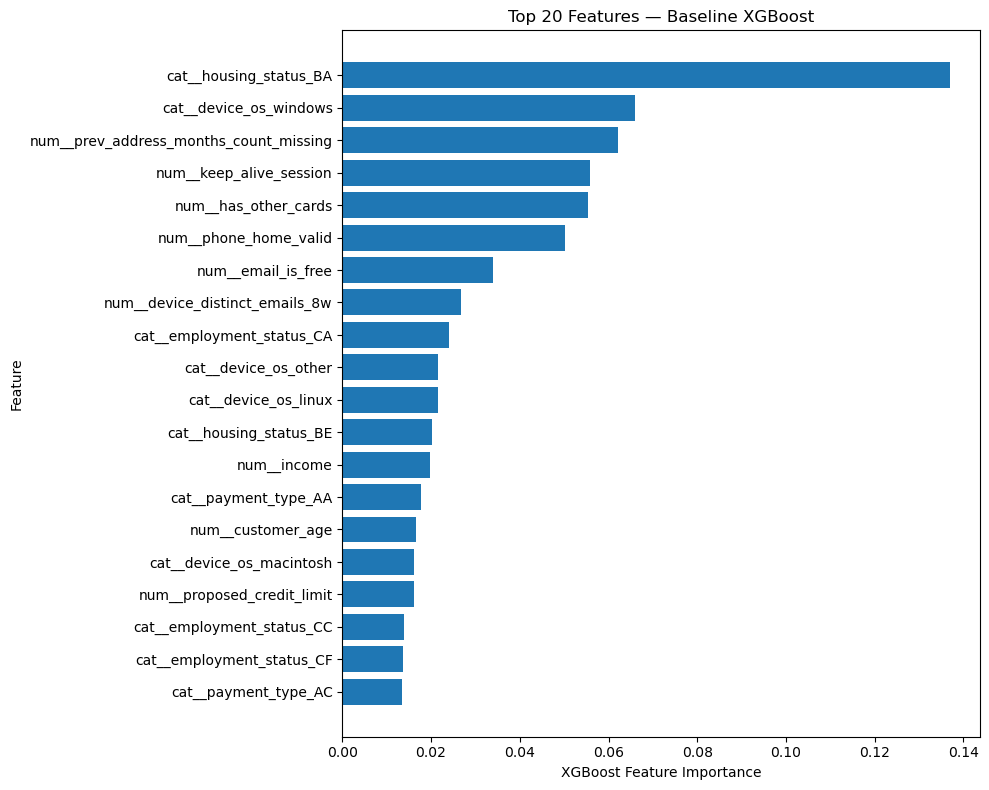

In [69]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20).sort_values(
    'importance'
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.xlabel('XGBoost Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Features — Baseline XGBoost')

plt.tight_layout()
plt.show()

In [70]:
zero_importance = feature_importance[
    feature_importance['importance'] == 0
]

print("Zero-importance features:", len(zero_importance))
print(zero_importance)

Zero-importance features: 1
                   feature  importance
54  cat__housing_status_BG         0.0


In [71]:
print([col for col in X_train.columns if 'missing' in col])

['prev_address_months_count_missing', 'current_address_months_count_missing', 'bank_months_count_missing', 'device_distinct_emails_8w_missing']


In [72]:
X_train_processed.shape

(700000, 55)

# ----------------------------     Phase 4 --------------------------

## Improving supervised model

In [73]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

depths = [4, 6, 8]

depth_results = []

for depth in depths:

    model_depth = XGBClassifier(
        n_estimators=300,
        max_depth=depth,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_depth.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_depth = model_depth.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_depth
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_depth
    )

    depth_results.append({
        'max_depth': depth,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

depth_results = pd.DataFrame(depth_results)

print(depth_results)

   max_depth    PR-AUC   ROC-AUC
0          4  0.171206  0.895162
1          6  0.164468  0.886097
2          8  0.135719  0.864256


In [74]:
child_weights = [1, 5, 10]

child_results = []

for weight in child_weights:

    model_child = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        min_child_weight=weight,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_child.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_child = model_child.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_child
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_child
    )

    child_results.append({
        'min_child_weight': weight,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

child_results = pd.DataFrame(child_results)

print(child_results)

   min_child_weight    PR-AUC   ROC-AUC
0                 1  0.171206  0.895162
1                 5  0.170136  0.895109
2                10  0.169408  0.894523


In [75]:
learning_configs = [
    (0.05, 500),
    (0.10, 300),
    (0.15, 200)
]

learning_results = []

for lr, n_est in learning_configs:

    model_lr = XGBClassifier(
        n_estimators=n_est,
        max_depth=4,
        min_child_weight=1,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_lr.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_lr = model_lr.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_lr
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_lr
    )

    learning_results.append({
        'learning_rate': lr,
        'n_estimators': n_est,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

learning_results = pd.DataFrame(learning_results)

print(learning_results)

   learning_rate  n_estimators    PR-AUC   ROC-AUC
0           0.05           500  0.173801  0.896297
1           0.10           300  0.171206  0.895162
2           0.15           200  0.167234  0.893779


In [76]:
subsample_configs = [0.6, 0.8, 1.0]

subsample_results = []

for subsample in subsample_configs:

    model_sub = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        min_child_weight=1,
        learning_rate=0.05,
        subsample=subsample,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_sub.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_sub = model_sub.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_sub
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_sub
    )

    subsample_results.append({
        'subsample': subsample,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

subsample_results = pd.DataFrame(subsample_results)

print(subsample_results)

   subsample    PR-AUC   ROC-AUC
0        0.6  0.172035  0.895541
1        0.8  0.173801  0.896297
2        1.0  0.171543  0.895215


In [77]:
colsample_configs = [0.6, 0.8, 1.0]

colsample_results = []

for colsample in colsample_configs:

    model_col = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        min_child_weight=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=colsample,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_col.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_col = model_col.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_col
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_col
    )

    colsample_results.append({
        'colsample_bytree': colsample,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

colsample_results = pd.DataFrame(colsample_results)

print(colsample_results)

   colsample_bytree    PR-AUC   ROC-AUC
0               0.6  0.173722  0.896134
1               0.8  0.173801  0.896297
2               1.0  0.171491  0.896309


In [78]:
alpha_configs = [0, 0.1, 1]

alpha_results = []

for alpha in alpha_configs:

    model_alpha = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        min_child_weight=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=alpha,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_alpha.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_alpha = model_alpha.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_alpha
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_alpha
    )

    alpha_results.append({
        'reg_alpha': alpha,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

alpha_results = pd.DataFrame(alpha_results)

print(alpha_results)

   reg_alpha    PR-AUC   ROC-AUC
0        0.0  0.173801  0.896297
1        0.1  0.173406  0.896398
2        1.0  0.173294  0.896278


In [79]:
lambda_configs = [0.5, 1.0, 5.0]

lambda_results = []

for reg_lambda in lambda_configs:

    model_lambda = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        min_child_weight=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    model_lambda.fit(
        X_train_processed,
        y_train
    )

    y_val_prob_lambda = model_lambda.predict_proba(
        X_val_processed
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        y_val_prob_lambda
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob_lambda
    )

    lambda_results.append({
        'reg_lambda': reg_lambda,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

lambda_results = pd.DataFrame(lambda_results)

print(lambda_results)

   reg_lambda    PR-AUC   ROC-AUC
0         0.5  0.172847  0.896375
1         1.0  0.173801  0.896297
2         5.0  0.172691  0.896660


In [80]:
model_final = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    min_child_weight=1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

In [81]:
model_final.fit(
    X_train_processed,
    y_train
)

y_train_prob_final = model_final.predict_proba(
    X_train_processed
)[:, 1]

y_val_prob_final = model_final.predict_proba(
    X_val_processed
)[:, 1]

train_pr_auc = average_precision_score(
    y_train,
    y_train_prob_final
)

val_pr_auc = average_precision_score(
    y_val,
    y_val_prob_final
)

train_roc_auc = roc_auc_score(
    y_train,
    y_train_prob_final
)

val_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_final
)

print("Train PR-AUC :", train_pr_auc)
print("Val PR-AUC   :", val_pr_auc)

print("Train ROC-AUC:", train_roc_auc)
print("Val ROC-AUC  :", val_roc_auc)

Train PR-AUC : 0.20500647863958893
Val PR-AUC   : 0.17380095718558775
Train ROC-AUC: 0.9282771566979549
Val ROC-AUC  : 0.896296625843305


In [82]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.05, 1.00, 0.05)

threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob_final >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    alerts = y_val_pred.sum()

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'alerts': alerts
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print(threshold_results)

    threshold  precision    recall        f1  alerts
0        0.05   0.014397  0.994562  0.028383  114330
1        0.10   0.018109  0.977039  0.035558   89294
2        0.15   0.021776  0.959517  0.042586   72924
3        0.20   0.025454  0.940181  0.049566   61130
4        0.25   0.029333  0.920846  0.056854   51956
5        0.30   0.033458  0.899094  0.064515   44474
6        0.35   0.037586  0.869486  0.072056   38286
7        0.40   0.042312  0.846526  0.080596   33111
8        0.45   0.047344  0.817523  0.089505   28578
9        0.50   0.052745  0.782477  0.098829   24552
10       0.55   0.058751  0.746224  0.108926   21021
11       0.60   0.065890  0.707553  0.120554   17772
12       0.65   0.074384  0.665861  0.133819   14815
13       0.70   0.085382  0.625378  0.150250   12122
14       0.75   0.100587  0.580060  0.171444    9544
15       0.80   0.120409  0.519033  0.195472    7134
16       0.85   0.146902  0.432628  0.219329    4874
17       0.90   0.192674  0.317825  0.239909  

In [83]:
fine_thresholds = np.arange(0.85, 0.951, 0.01)

fine_results = []

for threshold in fine_thresholds:

    y_pred = (
        y_val_prob_final >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    alerts = y_pred.sum()

    fine_results.append({
        'threshold': round(threshold, 2),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'alerts': alerts
    })

fine_results = pd.DataFrame(fine_results)

print(fine_results)

best_threshold_row = fine_results.loc[
    fine_results['f1'].idxmax()
]

print("\nF1-optimal threshold:")
print(best_threshold_row)


    threshold  precision    recall        f1  alerts
0        0.85   0.146902  0.432628  0.219329    4874
1        0.86   0.156172  0.418127  0.227407    4431
2        0.87   0.164506  0.398792  0.232927    4012
3        0.88   0.172871  0.370393  0.235724    3546
4        0.89   0.181935  0.343202  0.237806    3122
5        0.90   0.192674  0.317825  0.239909    2730
6        0.91   0.206282  0.293656  0.242334    2356
7        0.92   0.222845  0.264048  0.241704    1961
8        0.93   0.242848  0.230816  0.236679    1573
9        0.94   0.274510  0.203021  0.233414    1224
10       0.95   0.295930  0.162538  0.209828     909

F1-optimal threshold:
threshold       0.910000
precision       0.206282
recall          0.293656
f1              0.242334
alerts       2356.000000
Name: 6, dtype: float64


In [84]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Test probabilities
y_test_prob = model_final.predict_proba(
    X_test_processed
)[:, 1]

# Threshold selected using validation set
final_threshold = 0.91

y_test_pred = (
    y_test_prob >= final_threshold
).astype(int)

# Ranking metrics
test_pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

# Classification metrics
test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Final Test Results")
print("------------------")
print("PR-AUC    :", test_pr_auc)
print("ROC-AUC   :", test_roc_auc)
print("Precision :", test_precision)
print("Recall    :", test_recall)
print("F1        :", test_f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

Final Test Results
------------------
PR-AUC    : 0.17837696981348472
ROC-AUC   : 0.9031920737901691
Precision : 0.21355060034305318
Recall    : 0.3010882708585248
F1        : 0.2498745609633718

Confusion Matrix:
[[146512   1834]
 [  1156    498]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9922    0.9876    0.9899    148346
           1     0.2136    0.3011    0.2499      1654

    accuracy                         0.9801    150000
   macro avg     0.6029    0.6444    0.6199    150000
weighted avg     0.9836    0.9801    0.9817    150000



### conclusion : 
The XGBoost model was systematically tuned using validation PR-AUC as the primary metric. Controlled experiments identified a configuration with max_depth=4, min_child_weight=1, learning_rate=0.05, n_estimators=500, subsample=0.8, colsample_bytree=0.8, reg_alpha=0, and reg_lambda=1. The tuned model achieved a validation PR-AUC of 0.1738 and ROC-AUC of 0.8963. A validation-based threshold search selected 0.91 as the F1-optimal threshold among the tested values. On the untouched test set, the model achieved PR-AUC 0.1784, ROC-AUC 0.9032, precision 21.36%, recall 30.11%, and F1-score 24.99% at the selected threshold. The close validation and test performance indicates reasonable generalization.

## calibration 

In [85]:
from sklearn.metrics import brier_score_loss

brier_uncalibrated = brier_score_loss(
    y_val,
    y_val_prob_final
)

print("Uncalibrated Brier Score:", brier_uncalibrated)

Uncalibrated Brier Score: 0.11340316566883576


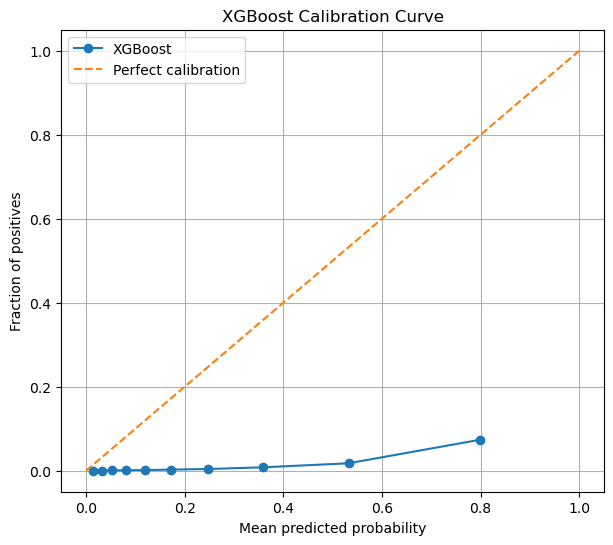

In [86]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_prob_final,
    n_bins=10,
    strategy='quantile'
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='XGBoost'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

In [87]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_sigmoid = CalibratedClassifierCV(
    estimator=XGBClassifier(
        n_estimators=500,
        max_depth=4,
        min_child_weight=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    ),
    method='sigmoid',
    cv=3
)

calibrated_sigmoid.fit(
    X_train_processed,
    y_train
)

CalibratedClassifierCV(cv=3,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.8,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='aucpr',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=4,
                                               max_leaves=None,
                                               min_child_weight=1, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=500, n_jobs=-1,
                                               num_parallel_tree=None, ...))

In [88]:
y_val_prob_sigmoid = calibrated_sigmoid.predict_proba(
    X_val_processed
)[:, 1]

In [89]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)

sigmoid_pr_auc = average_precision_score(
    y_val,
    y_val_prob_sigmoid
)

sigmoid_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_sigmoid
)

sigmoid_brier = brier_score_loss(
    y_val,
    y_val_prob_sigmoid
)

print("Sigmoid Calibration")
print("-------------------")
print("PR-AUC :", sigmoid_pr_auc)
print("ROC-AUC:", sigmoid_roc_auc)
print("Brier  :", sigmoid_brier)

Sigmoid Calibration
-------------------
PR-AUC : 0.17368935392753504
ROC-AUC: 0.8964509631392243
Brier  : 0.01007988807559077


In [90]:
calibrated_isotonic = CalibratedClassifierCV(
    estimator=XGBClassifier(
        n_estimators=500,
        max_depth=4,
        min_child_weight=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    ),
    method='isotonic',
    cv=3
)

calibrated_isotonic.fit(
    X_train_processed,
    y_train
)

CalibratedClassifierCV(cv=3,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.8,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='aucpr',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=4,
                                               max_leaves=None,
                                               min_child_weight=1, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=500, n_jobs=-1,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

In [91]:
y_val_prob_isotonic = calibrated_isotonic.predict_proba(
    X_val_processed
)[:, 1]

isotonic_pr_auc = average_precision_score(
    y_val,
    y_val_prob_isotonic
)

isotonic_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_isotonic
)

isotonic_brier = brier_score_loss(
    y_val,
    y_val_prob_isotonic
)

print("Isotonic Calibration")
print("--------------------")
print("PR-AUC :", isotonic_pr_auc)
print("ROC-AUC:", isotonic_roc_auc)
print("Brier  :", isotonic_brier)

Isotonic Calibration
--------------------
PR-AUC : 0.1738538082360403
ROC-AUC: 0.8964111665476463
Brier  : 0.009886283887815412


In [92]:
calibration_results = pd.DataFrame([
    {
        'Model': 'Uncalibrated',
        'PR-AUC': average_precision_score(
            y_val,
            y_val_prob_final
        ),
        'ROC-AUC': roc_auc_score(
            y_val,
            y_val_prob_final
        ),
        'Brier': brier_score_loss(
            y_val,
            y_val_prob_final
        )
    },
    {
        'Model': 'Sigmoid',
        'PR-AUC': sigmoid_pr_auc,
        'ROC-AUC': sigmoid_roc_auc,
        'Brier': sigmoid_brier
    },
    {
        'Model': 'Isotonic',
        'PR-AUC': isotonic_pr_auc,
        'ROC-AUC': isotonic_roc_auc,
        'Brier': isotonic_brier
    }
])

print(calibration_results)

          Model    PR-AUC   ROC-AUC     Brier
0  Uncalibrated  0.173801  0.896297  0.113403
1       Sigmoid  0.173689  0.896451  0.010080
2      Isotonic  0.173854  0.896411  0.009886


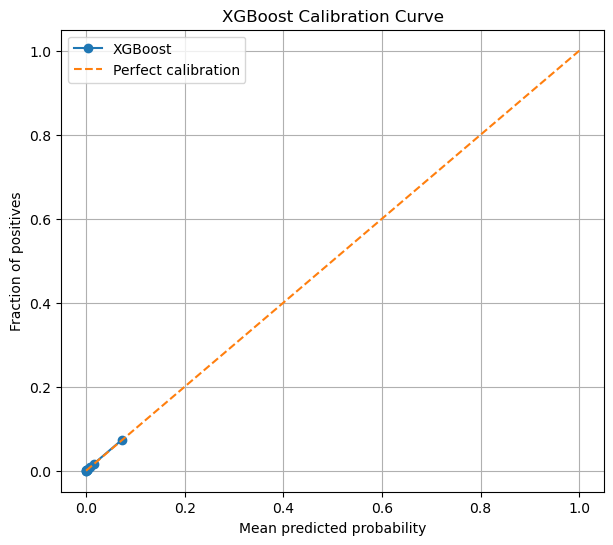

In [93]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_prob_isotonic,
    n_bins=10,
    strategy='quantile'
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='XGBoost'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

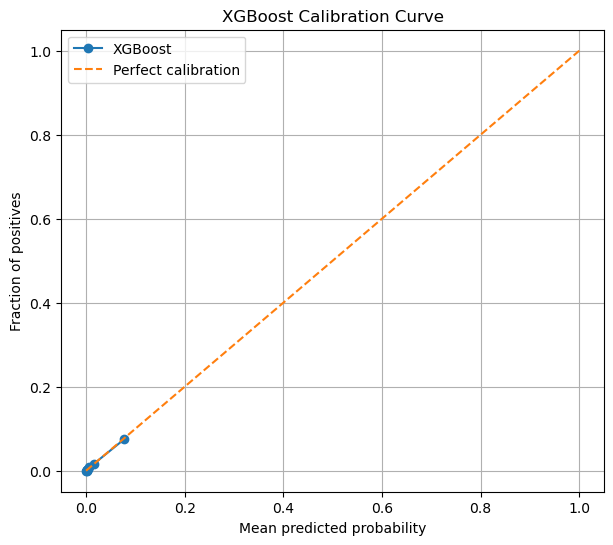

In [94]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_prob_sigmoid,
    n_bins=10,
    strategy='quantile'
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='XGBoost'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

In [95]:
calibrated_thresholds = np.arange(0.05, 1.00, 0.05)

calibrated_threshold_results = []

for threshold in calibrated_thresholds:

    y_pred = (
        y_val_prob_isotonic >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    alerts = y_pred.sum()

    calibrated_threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'alerts': alerts
    })

calibrated_threshold_results = pd.DataFrame(
    calibrated_threshold_results
)

print(calibrated_threshold_results)

    threshold  precision    recall        f1  alerts
0        0.05   0.123163  0.516616  0.198907    6942
1        0.10   0.188647  0.335347  0.241462    2942
2        0.15   0.261242  0.221148  0.239529    1401
3        0.20   0.304556  0.153474  0.204098     834
4        0.25   0.353659  0.105136  0.162087     492
5        0.30   0.414474  0.076133  0.128637     304
6        0.35   0.478049  0.059215  0.105376     205
7        0.40   0.538462  0.046526  0.085651     143
8        0.45   0.632911  0.030211  0.057670      79
9        0.50   0.695652  0.019335  0.037625      46
10       0.55   0.676471  0.013897  0.027235      34
11       0.60   0.689655  0.012085  0.023753      29
12       0.65   0.750000  0.009063  0.017910      20
13       0.70   0.818182  0.005438  0.010804      11
14       0.75   0.875000  0.004230  0.008419       8
15       0.80   1.000000  0.003021  0.006024       5
16       0.85   1.000000  0.002417  0.004822       4
17       0.90   1.000000  0.001813  0.003619  

In [96]:
best_calibrated = calibrated_threshold_results.loc[
    calibrated_threshold_results['f1'].idxmax()
]

print(best_calibrated)

threshold       0.100000
precision       0.188647
recall          0.335347
f1              0.241462
alerts       2942.000000
Name: 1, dtype: float64


In [97]:
fine_calibrated_thresholds = np.arange(
    0.05, 0.151, 0.005
)

fine_calibrated_results = []

for threshold in fine_calibrated_thresholds:

    y_pred = (
        y_val_prob_isotonic >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    alerts = y_pred.sum()

    fine_calibrated_results.append({
        'threshold': round(threshold, 3),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'alerts': alerts
    })

fine_calibrated_results = pd.DataFrame(
    fine_calibrated_results
)

print(fine_calibrated_results)

best_calibrated_threshold = fine_calibrated_results.loc[
    fine_calibrated_results['f1'].idxmax()
]

print("\nFine-grained F1-optimal threshold:")
print(best_calibrated_threshold)

    threshold  precision    recall        f1  alerts
0       0.050   0.123163  0.516616  0.198907    6942
1       0.055   0.129466  0.494864  0.205237    6326
2       0.060   0.135798  0.474924  0.211205    5788
3       0.065   0.142201  0.448943  0.215988    5225
4       0.070   0.149457  0.432024  0.222084    4784
5       0.075   0.155219  0.415106  0.225950    4426
6       0.080   0.164164  0.403021  0.233298    4063
7       0.085   0.170915  0.384894  0.236715    3727
8       0.090   0.181312  0.374018  0.244230    3414
9       0.095   0.184665  0.349245  0.241588    3130
10      0.100   0.188647  0.335347  0.241462    2942
11      0.105   0.196997  0.325076  0.245326    2731
12      0.110   0.202778  0.308761  0.244790    2520
13      0.115   0.207587  0.294260  0.243439    2346
14      0.120   0.215455  0.286405  0.245914    2200
15      0.125   0.224173  0.270091  0.244999    1994
16      0.130   0.227929  0.257402  0.241771    1869
17      0.135   0.235968  0.248943  0.242282  

In [98]:
y_test_prob_calibrated = calibrated_isotonic.predict_proba(
    X_test_processed
)[:, 1]

final_calibrated_threshold = 0.12

y_test_pred_calibrated = (
    y_test_prob_calibrated >= final_calibrated_threshold
).astype(int)

In [99]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

test_pr_auc_calibrated = average_precision_score(
    y_test,
    y_test_prob_calibrated
)

test_roc_auc_calibrated = roc_auc_score(
    y_test,
    y_test_prob_calibrated
)

test_precision_calibrated = precision_score(
    y_test,
    y_test_pred_calibrated,
    zero_division=0
)

test_recall_calibrated = recall_score(
    y_test,
    y_test_pred_calibrated,
    zero_division=0
)

test_f1_calibrated = f1_score(
    y_test,
    y_test_pred_calibrated,
    zero_division=0
)

test_brier_calibrated = brier_score_loss(
    y_test,
    y_test_prob_calibrated
)

cm_calibrated = confusion_matrix(
    y_test,
    y_test_pred_calibrated
)

print("Final Calibrated Test Results")
print("-----------------------------")
print("PR-AUC    :", test_pr_auc_calibrated)
print("ROC-AUC   :", test_roc_auc_calibrated)
print("Precision :", test_precision_calibrated)
print("Recall    :", test_recall_calibrated)
print("F1        :", test_f1_calibrated)
print("Brier     :", test_brier_calibrated)

print("\nConfusion Matrix:")
print(cm_calibrated)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_calibrated,
        digits=4
    )
)

Final Calibrated Test Results
-----------------------------
PR-AUC    : 0.17749387248614248
ROC-AUC   : 0.9036803090705736
Precision : 0.21493624772313297
Recall    : 0.28536880290205563
F1        : 0.2451948051948052
Brier     : 0.00983953773095372

Confusion Matrix:
[[146622   1724]
 [  1182    472]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9920    0.9884    0.9902    148346
           1     0.2149    0.2854    0.2452      1654

    accuracy                         0.9806    150000
   macro avg     0.6035    0.6369    0.6177    150000
weighted avg     0.9834    0.9806    0.9820    150000



# ------- Phase 5 - Unsupervised Anomaly Detection------

In [100]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=300,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_processed)

IsolationForest(n_estimators=300, n_jobs=-1, random_state=42)

In [101]:
iso_val_score = -iso_model.score_samples(X_val_processed)

In [102]:
from sklearn.metrics import average_precision_score, roc_auc_score

iso_pr_auc = average_precision_score(
    y_val,
    iso_val_score
)

iso_roc_auc = roc_auc_score(
    y_val,
    iso_val_score
)

print("Isolation Forest Validation Results")
print("-----------------------------------")
print("PR-AUC :", iso_pr_auc)
print("ROC-AUC:", iso_roc_auc)

Isolation Forest Validation Results
-----------------------------------
PR-AUC : 0.012949672029481553
ROC-AUC: 0.5395605227016838


In [103]:
import pandas as pd

score_df = pd.DataFrame({
    'anomaly_score': iso_val_score,
    'fraud': y_val.values
})

print(
    score_df.groupby('fraud')['anomaly_score'].describe()
)

          count      mean       std       min       25%       50%       75%  \
fraud                                                                         
0      148345.0  0.464469  0.027098  0.397163  0.444279  0.461830  0.481936   
1        1655.0  0.468672  0.027819  0.408634  0.448291  0.464824  0.485748   

            max  
fraud            
0      0.617017  
1      0.569404  


In [104]:
xgb_val_prob = calibrated_isotonic.predict_proba(
    X_val_processed
)[:, 1]

correlation = np.corrcoef(
    xgb_val_prob,
    iso_val_score
)[0, 1]

print("XGBoost ↔ Isolation Forest correlation:", correlation)

XGBoost ↔ Isolation Forest correlation: 0.01949160793217366


In [105]:
import numpy as np

for percentile in [99, 98, 95, 90]:
    threshold = np.percentile(iso_val_score, percentile)

    mask = iso_val_score >= threshold

    fraud_rate = y_val.values[mask].mean()
    count = mask.sum()

    print(f"Top {100 - percentile}% most anomalous:")
    print("Count:", count)
    print("Fraud rate:", fraud_rate)
    print()

Top 1% most anomalous:
Count: 1500
Fraud rate: 0.023333333333333334

Top 2% most anomalous:
Count: 3000
Fraud rate: 0.018

Top 5% most anomalous:
Count: 7500
Fraud rate: 0.0156

Top 10% most anomalous:
Count: 15000
Fraud rate: 0.015333333333333332



In [106]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

iso_val_norm = scaler.fit_transform(
    iso_val_score.reshape(-1, 1)
).ravel()

xgb_val_norm = xgb_val_prob

In [107]:
from sklearn.metrics import average_precision_score, roc_auc_score

weights = [0.9, 0.8, 0.7, 0.6, 0.5]

for alpha in weights:
    combined_score = (
        alpha * xgb_val_norm
        + (1 - alpha) * iso_val_norm
    )

    pr_auc = average_precision_score(
        y_val,
        combined_score
    )

    roc_auc = roc_auc_score(
        y_val,
        combined_score
    )

    print(
        f"XGB weight={alpha:.1f} | "
        f"IF weight={1-alpha:.1f} | "
        f"PR-AUC={pr_auc:.6f} | "
        f"ROC-AUC={roc_auc:.6f}"
    )

XGB weight=0.9 | IF weight=0.1 | PR-AUC=0.166436 | ROC-AUC=0.842787
XGB weight=0.8 | IF weight=0.2 | PR-AUC=0.147271 | ROC-AUC=0.793416
XGB weight=0.7 | IF weight=0.3 | PR-AUC=0.121104 | ROC-AUC=0.751069
XGB weight=0.6 | IF weight=0.4 | PR-AUC=0.091792 | ROC-AUC=0.712611
XGB weight=0.5 | IF weight=0.5 | PR-AUC=0.061556 | ROC-AUC=0.677605


# PHASE 6 - SHAP

In [108]:
!pip install shap

In [109]:
import shap

In [110]:
fitted_xgb = calibrated_isotonic.calibrated_classifiers_[0].estimator

explainer = shap.TreeExplainer(fitted_xgb)

In [111]:
X_shap = X_val_processed[:10000]

shap_values = explainer.shap_values(X_shap)

print("SHAP shape:", shap_values.shape)

SHAP shape: (10000, 55)


In [112]:
feature_names = preprocessor.get_feature_names_out()

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
)

print(shap_importance.head(15))

                                   feature  mean_abs_shap
41                  cat__housing_status_BA       0.511402
53                  cat__device_os_windows       0.417484
15                   num__phone_home_valid       0.393635
22                 num__keep_alive_session       0.376641
18                    num__has_other_cards       0.343633
1               num__name_email_similarity       0.324145
25  num__prev_address_months_count_missing       0.322524
3        num__current_address_months_count       0.285160
0                              num__income       0.273786
14                      num__email_is_free       0.260326
11               num__bank_branch_count_8w       0.220051
6              num__intended_balcon_amount       0.197063
13                  num__credit_risk_score       0.166055
10                        num__velocity_4w       0.156407
5                  num__days_since_request       0.152509


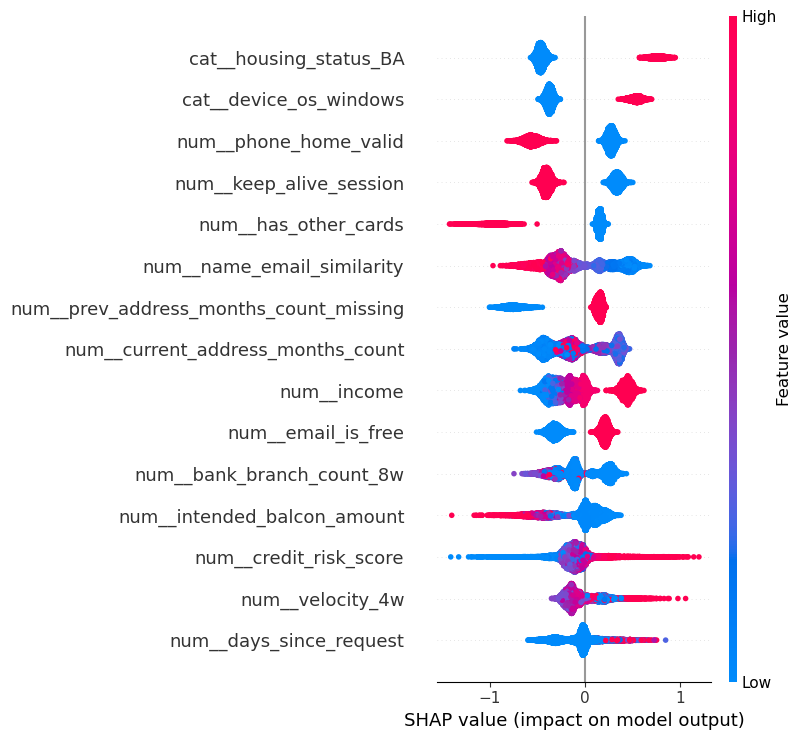

In [113]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=15
)

In [114]:
fraud_indices = np.where(y_val.values == 1)[0]

idx = fraud_indices[0]

print("Validation index:", idx)

Validation index: 130


In [115]:
fraud_sample = X_val_processed[idx:idx+1]

fraud_probability = calibrated_isotonic.predict_proba(
    fraud_sample
)[:, 1][0]

print("Calibrated fraud probability:", fraud_probability)

Calibrated fraud probability: 0.03862414509057999


In [116]:
fraud_shap = explainer.shap_values(
    fraud_sample
)[0]

fraud_explanation = pd.DataFrame({
    'feature': feature_names,
    'shap_value': fraud_shap,
    'feature_value': X_val_processed[idx].ravel()
})

fraud_explanation['abs_shap'] = np.abs(
    fraud_explanation['shap_value']
)

fraud_explanation = fraud_explanation.sort_values(
    'abs_shap',
    ascending=False
)

print(fraud_explanation.head(10))

                              feature  shap_value  feature_value  abs_shap
1          num__name_email_similarity    0.532053        0.06753  0.532053
41             cat__housing_status_BA   -0.459250        0.00000  0.459250
53             cat__device_os_windows   -0.374198        0.00000  0.374198
22            num__keep_alive_session    0.346898        0.00000  0.346898
14                 num__email_is_free   -0.343186        0.00000  0.343186
15              num__phone_home_valid    0.270314        0.00000  0.270314
10                   num__velocity_4w    0.265839     4110.23186  0.265839
4                   num__customer_age   -0.224159       20.00000  0.224159
3   num__current_address_months_count    0.212992       49.00000  0.212992
17             num__bank_months_count    0.199474       31.00000  0.199474


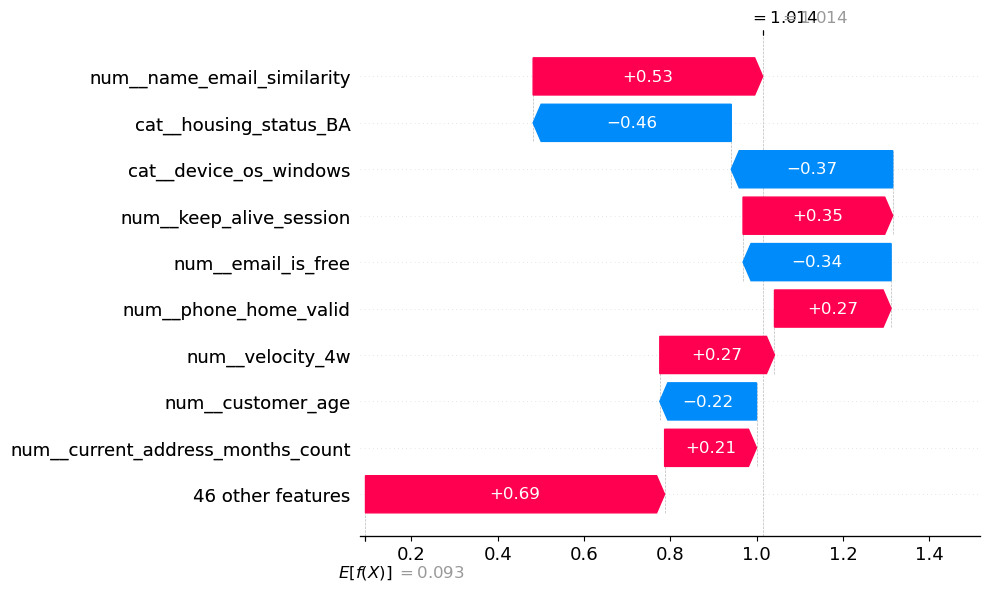

In [117]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    fraud_shap,
    feature_names=feature_names,
    max_display=10
)

# ------- PHASE - 7 Temporal Evaluation & Time-Based Robustness------ 

In [118]:
# CELL 1 — Save Phase 1-6 Models and Preprocessing

import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(preprocessor, "artifacts/preprocessor.pkl")
joblib.dump(calibrated_isotonic, "artifacts/calibrated_xgb.pkl")

print("Preprocessor saved.")
print("Calibrated XGBoost saved.")

Preprocessor saved.
Calibrated XGBoost saved.


In [119]:
# CELL 2 — Save Processed Datasets

import numpy as np

np.save(
    "artifacts/X_train_processed.npy",
    X_train_processed
)

np.save(
    "artifacts/X_val_processed.npy",
    X_val_processed
)

np.save(
    "artifacts/X_test_processed.npy",
    X_test_processed
)

print("Processed datasets saved successfully.")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Processed datasets saved successfully.
Train: (700000, 55)
Validation: (150000, 55)
Test: (150000, 55)


In [120]:
# CELL 3 — Save Target Variables

import numpy as np

np.save("artifacts/y_train.npy", np.asarray(y_train))
np.save("artifacts/y_val.npy", np.asarray(y_val))
np.save("artifacts/y_test.npy", np.asarray(y_test))

print("Target variables saved successfully.")
print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

Target variables saved successfully.
Train: 700000
Validation: 150000
Test: 150000


In [121]:
# CELL 4 — Save SHAP Results

import numpy as np

np.save(
    "artifacts/shap_values.npy",
    shap_values
)

np.save(
    "artifacts/fraud_shap.npy",
    fraud_shap
)

with open("artifacts/feature_names.txt", "w") as f:
    for feature in feature_names:
        f.write(str(feature) + "\n")

print("SHAP results saved successfully.")
print("SHAP shape:", shap_values.shape)
print("Number of feature names:", len(feature_names))

SHAP results saved successfully.
SHAP shape: (10000, 55)
Number of feature names: 55


In [122]:
# CELL 5 — Save Final Model Results

import json

results = {
    "validation_pr_auc": 0.17380095718558775,
    "validation_roc_auc": 0.896296625843305,

    "test_pr_auc": 0.17749387248614248,
    "test_roc_auc": 0.9036803090705736,

    "test_precision": 0.21493624772313297,
    "test_recall": 0.28536880290205563,
    "test_f1": 0.2451948051948052,
    "test_brier": 0.00983953773095372,

    "selected_threshold": 0.12,

    "isolation_forest_pr_auc": 0.012949672029481553,
    "isolation_forest_roc_auc": 0.5395605227016838
}

with open("artifacts/results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Final results saved successfully.")

Final results saved successfully.


In [123]:
# CELL 6 — Verify Saved Phase 1-6 Artifacts

import os
import json
import joblib
import numpy as np

artifact_dir = "artifacts"

# Check files
required_files = [
    "preprocessor.pkl",
    "calibrated_xgb.pkl",
    "X_train_processed.npy",
    "X_val_processed.npy",
    "X_test_processed.npy",
    "y_train.npy",
    "y_val.npy",
    "y_test.npy",
    "shap_values.npy",
    "fraud_shap.npy",
    "feature_names.txt",
    "results.json"
]

print("Checking artifacts...\n")

for file in required_files:
    path = os.path.join(artifact_dir, file)
    print(f"{file}: {'FOUND' if os.path.exists(path) else 'MISSING'}")

# Load important artifacts
preprocessor = joblib.load(
    "artifacts/preprocessor.pkl"
)

calibrated_isotonic = joblib.load(
    "artifacts/calibrated_xgb.pkl"
)

X_train_processed = np.load(
    "artifacts/X_train_processed.npy"
)

X_val_processed = np.load(
    "artifacts/X_val_processed.npy"
)

X_test_processed = np.load(
    "artifacts/X_test_processed.npy"
)

y_train = np.load(
    "artifacts/y_train.npy"
)

y_val = np.load(
    "artifacts/y_val.npy"
)

y_test = np.load(
    "artifacts/y_test.npy"
)

shap_values = np.load(
    "artifacts/shap_values.npy"
)

fraud_shap = np.load(
    "artifacts/fraud_shap.npy"
)

with open("artifacts/feature_names.txt", "r") as f:
    feature_names = [line.strip() for line in f]

with open("artifacts/results.json", "r") as f:
    results = json.load(f)

print("\nAll artifacts loaded successfully.")

print("\nShapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)
print("SHAP:", shap_values.shape)
print("Feature names:", len(feature_names))

Checking artifacts...

preprocessor.pkl: FOUND
calibrated_xgb.pkl: FOUND
X_train_processed.npy: FOUND
X_val_processed.npy: FOUND
X_test_processed.npy: FOUND
y_train.npy: FOUND
y_val.npy: FOUND
y_test.npy: FOUND
shap_values.npy: FOUND
fraud_shap.npy: FOUND
feature_names.txt: FOUND
results.json: FOUND

All artifacts loaded successfully.

Shapes:
X_train_processed: (700000, 55)
X_val_processed: (150000, 55)
X_test_processed: (150000, 55)
y_train: (700000,)
y_val: (150000,)
y_test: (150000,)
SHAP: (10000, 55)
Feature names: 55


In [125]:
# CELL 8 — Find BAF Dataset File

import time
from pathlib import Path

start_time = time.perf_counter()

search_locations = [
    Path.cwd(),
    Path.home() / "Documents",
    Path.home() / "Downloads",
    Path.home() / "Desktop",
]

matches = []

for location in search_locations:
    if location.exists():
        for pattern in ["*.csv", "*.CSV"]:
            matches.extend(location.rglob(pattern))

print("CSV files found:\n")

for path in matches:
    print(path)

print(f"\nTotal CSV files found: {len(matches)}")
print(f"Cell runtime: {time.perf_counter() - start_time:.4f} seconds")

CSV files found:

C:\Users\mayan\Documents\projects\.ipynb_checkpoints\netflix_cleaned-checkpoint.csv
C:\Users\mayan\Documents\projects\.ipynb_checkpoints\netflix_titles-checkpoint.csv
C:\Users\mayan\Documents\projects\Data\netflix_cleaned.csv
C:\Users\mayan\Documents\projects\Data\netflix_titles.csv
C:\Users\mayan\Documents\projects\regression\Advertising.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\ADANIPORTS.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\ASIANPAINT.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\AXISBANK.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\BAJAJ-AUTO.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\BAJAJFINSV.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\BAJFINANCE.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\BHARTIARTL.csv
C:\Users\mayan\Documents\projects\stock_prediction\datasets\BPCL.csv
C:\Users\mayan\Documents\projects\stock_predi

In [126]:
# CELL 8 — Search for BAF Dataset

import time
from pathlib import Path

start_time = time.perf_counter()

search_root = Path.home() / "Documents"

patterns = [
    "*BAF*.csv",
    "*baf*.csv",
    "*fraud*.csv",
    "*base*.csv"
]

matches = []

for pattern in patterns:
    matches.extend(search_root.rglob(pattern))

# Remove duplicates
matches = list(dict.fromkeys(matches))

print("Possible BAF/Fraud dataset files:\n")

for path in matches:
    print(path)

print(f"\nTotal candidates found: {len(matches)}")
print(f"Cell runtime: {time.perf_counter() - start_time:.4f} seconds")

Possible BAF/Fraud dataset files:

C:\Users\mayan\Documents\projects\FRAUD_TRANSACTION_DETECTION_SYSTEM\datasets\Base.csv

Total candidates found: 1
Cell runtime: 16.6208 seconds


In [127]:
# CELL 9 — Verify Original BAF Dataset

import time
import pandas as pd

start_time = time.perf_counter()

DATA_PATH = r"C:\Users\mayan\Documents\projects\FRAUD_TRANSACTION_DETECTION_SYSTEM\datasets\Base.csv"

df_temporal = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_temporal.shape)

print("\nColumns:")
print(df_temporal.columns.tolist())

print("\nMonth values:")
print(sorted(df_temporal["month"].unique()))

print("\nTarget distribution:")
print(df_temporal["fraud_bool"].value_counts())

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Dataset loaded successfully.
Shape: (1000000, 32)

Columns:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']

Month values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Target distribution:
fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Cell runtime: 2.3881 seconds


In [128]:
# CELL 10 — Phase 7: Monthly Distribution Analysis

import time
import pandas as pd

start_time = time.perf_counter()

monthly_stats = (
    df_temporal
    .groupby("month")
    .agg(
        total_samples=("fraud_bool", "size"),
        fraud_count=("fraud_bool", "sum"),
        fraud_rate=("fraud_bool", "mean")
    )
    .reset_index()
)

monthly_stats["fraud_rate_pct"] = monthly_stats["fraud_rate"] * 100

print("Monthly Distribution:\n")
print(monthly_stats.to_string(index=False))

print("\nTotal samples:", len(df_temporal))
print("Total fraud:", df_temporal["fraud_bool"].sum())
print("Overall fraud rate:",
      df_temporal["fraud_bool"].mean() * 100, "%")

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Monthly Distribution:

 month  total_samples  fraud_count  fraud_rate  fraud_rate_pct
     0         132440         1500    0.011326        1.132588
     1         127620         1198    0.009387        0.938724
     2         136979         1198    0.008746        0.874587
     3         150936         1392    0.009222        0.922245
     4         127691         1452    0.011371        1.137120
     5         119323         1411    0.011825        1.182505
     6         108168         1450    0.013405        1.340507
     7          96843         1428    0.014746        1.474552

Total samples: 1000000
Total fraud: 11029
Overall fraud rate: 1.1029 %

Cell runtime: 0.0511 seconds


In [129]:
# CELL 11 — Phase 7: Reload Dataset + Chronological Split

import time
import pandas as pd

start_time = time.perf_counter()

DATA_PATH = r"C:\Users\mayan\Documents\projects\FRAUD_TRANSACTION_DETECTION_SYSTEM\datasets\Base.csv"

# Reload dataset after kernel restart
df_temporal = pd.read_csv(DATA_PATH)

# Chronological boundaries
train_months = [0, 1, 2, 3, 4]
val_months = [5]
test_months = [6, 7]

# Create masks
train_mask = df_temporal["month"].isin(train_months)
val_mask = df_temporal["month"].isin(val_months)
test_mask = df_temporal["month"].isin(test_months)

# Create chronological datasets
df_chrono_train = df_temporal.loc[train_mask].copy()
df_chrono_val = df_temporal.loc[val_mask].copy()
df_chrono_test = df_temporal.loc[test_mask].copy()

print("Chronological Split")
print("=" * 60)

print("\nTRAIN — Months 0–4")
print("Shape:", df_chrono_train.shape)
print("Fraud rate:", df_chrono_train["fraud_bool"].mean() * 100, "%")

print("\nVALIDATION — Month 5")
print("Shape:", df_chrono_val.shape)
print("Fraud rate:", df_chrono_val["fraud_bool"].mean() * 100, "%")

print("\nTEST — Months 6–7")
print("Shape:", df_chrono_test.shape)
print("Fraud rate:", df_chrono_test["fraud_bool"].mean() * 100, "%")

print("\nTotal rows:",
      len(df_chrono_train)
      + len(df_chrono_val)
      + len(df_chrono_test))

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Chronological Split

TRAIN — Months 0–4
Shape: (675666, 32)
Fraud rate: 0.9975342846909568 %

VALIDATION — Month 5
Shape: (119323, 32)
Fraud rate: 1.182504630289215 %

TEST — Months 6–7
Shape: (205011, 32)
Fraud rate: 1.4038271117159566 %

Total rows: 1000000

Cell runtime: 3.1706 seconds


In [134]:
# CELL 12 — Phase 7: Prepare Chronological Features

import time
import numpy as np

start_time = time.perf_counter()

TARGET = "fraud_bool"

# Separate target
y_chrono_train = df_chrono_train[TARGET].copy()
y_chrono_val = df_chrono_val[TARGET].copy()
y_chrono_test = df_chrono_test[TARGET].copy()

# Remove target
X_chrono_train = df_chrono_train.drop(columns=[TARGET]).copy()
X_chrono_val = df_chrono_val.drop(columns=[TARGET]).copy()
X_chrono_test = df_chrono_test.drop(columns=[TARGET]).copy()

# Drop constant feature identified during Phase 1
X_chrono_train.drop(columns=["device_fraud_count"], inplace=True)
X_chrono_val.drop(columns=["device_fraud_count"], inplace=True)
X_chrono_test.drop(columns=["device_fraud_count"], inplace=True)

# Sentinel columns
sentinel_cols = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
    "device_distinct_emails_8w"
]

# Create missing indicators
for col in sentinel_cols:
    X_chrono_train[col + "_missing"] = (
        X_chrono_train[col] == -1
    ).astype(int)

    X_chrono_val[col + "_missing"] = (
        X_chrono_val[col] == -1
    ).astype(int)

    X_chrono_test[col + "_missing"] = (
        X_chrono_test[col] == -1
    ).astype(int)

# Replace sentinel -1 with NaN
for col in sentinel_cols:
    X_chrono_train[col] = X_chrono_train[col].replace(-1, np.nan)
    X_chrono_val[col] = X_chrono_val[col].replace(-1, np.nan)
    X_chrono_test[col] = X_chrono_test[col].replace(-1, np.nan)

print("Chronological feature preparation complete.")

print("\nShapes:")
print("X_train:", X_chrono_train.shape)
print("X_val  :", X_chrono_val.shape)
print("X_test :", X_chrono_test.shape)

print("\nTarget shapes:")
print("y_train:", y_chrono_train.shape)
print("y_val  :", y_chrono_val.shape)
print("y_test :", y_chrono_test.shape)

print("\nMissing indicators:")
print([
    col for col in X_chrono_train.columns
    if col.endswith("_missing")
])

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Chronological feature preparation complete.

Shapes:
X_train: (675666, 34)
X_val  : (119323, 34)
X_test : (205011, 34)

Target shapes:
y_train: (675666,)
y_val  : (119323,)
y_test : (205011,)

Missing indicators:
['prev_address_months_count_missing', 'current_address_months_count_missing', 'bank_months_count_missing', 'device_distinct_emails_8w_missing']

Cell runtime: 0.3702 seconds


In [135]:
# CELL 13 — Phase 7: Fit Preprocessor on Chronological Train Only

import time
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

start_time = time.perf_counter()

categorical_cols = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]

numerical_cols = [
    "income",
    "name_email_similarity",
    "prev_address_months_count",
    "current_address_months_count",
    "customer_age",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "velocity_24h",
    "velocity_4w",
    "bank_branch_count_8w",
    "date_of_birth_distinct_emails_4w",
    "credit_risk_score",
    "email_is_free",
    "phone_home_valid",
    "phone_mobile_valid",
    "bank_months_count",
    "has_other_cards",
    "proposed_credit_limit",
    "foreign_request",
    "session_length_in_minutes",
    "keep_alive_session",
    "device_distinct_emails_8w",
    "month",
    "prev_address_months_count_missing",
    "current_address_months_count_missing",
    "bank_months_count_missing",
    "device_distinct_emails_8w_missing"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

chrono_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# IMPORTANT:
# Fit ONLY on chronological training data.
X_chrono_train_processed = chrono_preprocessor.fit_transform(
    X_chrono_train
)

# Transform future periods using the train-fitted preprocessor.
X_chrono_val_processed = chrono_preprocessor.transform(
    X_chrono_val
)

X_chrono_test_processed = chrono_preprocessor.transform(
    X_chrono_test
)

print("Chronological preprocessing complete.")

print("\nProcessed shapes:")
print("Train:", X_chrono_train_processed.shape)
print("Val  :", X_chrono_val_processed.shape)
print("Test :", X_chrono_test_processed.shape)

print("\nNaN check:")
print("Train:", np.isnan(X_chrono_train_processed).sum())
print("Val  :", np.isnan(X_chrono_val_processed).sum())
print("Test :", np.isnan(X_chrono_test_processed).sum())

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Chronological preprocessing complete.

Processed shapes:
Train: (675666, 55)
Val  : (119323, 55)
Test : (205011, 55)

NaN check:
Train: 0
Val  : 0
Test : 0

Cell runtime: 4.0073 seconds


In [136]:
# CELL 14 — Phase 7: Train Chronological XGBoost

import time
from xgboost import XGBClassifier

start_time = time.perf_counter()

# Chronological training fraud ratio
fraud_rate_train = y_chrono_train.mean()

scale_pos_weight_chrono = (
    (1 - fraud_rate_train) / fraud_rate_train
)

print(f"Chronological train fraud rate: {fraud_rate_train:.6f}")
print(f"scale_pos_weight: {scale_pos_weight_chrono:.4f}")

# Same tuned configuration selected in Phase 4
chrono_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    min_child_weight=1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight_chrono,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

chrono_xgb.fit(
    X_chrono_train_processed,
    y_chrono_train
)

print("\nChronological XGBoost training complete.")

print(
    f"\nCell runtime: "
    f"{time.perf_counter() - start_time:.4f} seconds"
)

Chronological train fraud rate: 0.009975
scale_pos_weight: 99.2472

Chronological XGBoost training complete.

Cell runtime: 13.5706 seconds


In [137]:
# CELL 15 — Phase 7: Raw XGBoost Temporal Evaluation

import time
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

start_time = time.perf_counter()

# Predictions
chrono_val_proba = chrono_xgb.predict_proba(
    X_chrono_val_processed
)[:, 1]

chrono_test_proba = chrono_xgb.predict_proba(
    X_chrono_test_processed
)[:, 1]

# Validation metrics
val_pr_auc = average_precision_score(
    y_chrono_val,
    chrono_val_proba
)

val_roc_auc = roc_auc_score(
    y_chrono_val,
    chrono_val_proba
)

# Test metrics
test_pr_auc = average_precision_score(
    y_chrono_test,
    chrono_test_proba
)

test_roc_auc = roc_auc_score(
    y_chrono_test,
    chrono_test_proba
)

print("CHRONOLOGICAL VALIDATION")
print("=" * 60)
print(f"PR-AUC :  {val_pr_auc:.6f}")
print(f"ROC-AUC:  {val_roc_auc:.6f}")

print("\nCHRONOLOGICAL TEST")
print("=" * 60)
print(f"PR-AUC :  {test_pr_auc:.6f}")
print(f"ROC-AUC:  {test_roc_auc:.6f}")

# Default threshold diagnostics
threshold = 0.5

val_pred = (chrono_val_proba >= threshold).astype(int)
test_pred = (chrono_test_proba >= threshold).astype(int)

print("\nValidation @ threshold 0.50")
print(f"Precision: {precision_score(y_chrono_val, val_pred):.6f}")
print(f"Recall   : {recall_score(y_chrono_val, val_pred):.6f}")
print(f"F1       : {f1_score(y_chrono_val, val_pred):.6f}")
print("Confusion Matrix:")
print(confusion_matrix(y_chrono_val, val_pred))

print("\nTest @ threshold 0.50")
print(f"Precision: {precision_score(y_chrono_test, test_pred):.6f}")
print(f"Recall   : {recall_score(y_chrono_test, test_pred):.6f}")
print(f"F1       : {f1_score(y_chrono_test, test_pred):.6f}")
print("Confusion Matrix:")
print(confusion_matrix(y_chrono_test, test_pred))

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

CHRONOLOGICAL VALIDATION
PR-AUC :  0.191810
ROC-AUC:  0.896511

CHRONOLOGICAL TEST
PR-AUC :  0.194496
ROC-AUC:  0.893650

Validation @ threshold 0.50
Precision: 0.066570
Recall   : 0.715096
F1       : 0.121801
Confusion Matrix:
[[103764  14148]
 [   402   1009]]

Test @ threshold 0.50
Precision: 0.079358
Recall   : 0.731758
F1       : 0.143187
Confusion Matrix:
[[177701  24432]
 [   772   2106]]

Cell runtime: 0.6501 seconds


In [138]:
# CELL 16 — Phase 7: Monthly Model Performance

import time
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

start_time = time.perf_counter()

monthly_results = []

for month in sorted(df_chrono_test["month"].unique()):

    mask = df_chrono_test["month"].values == month

    y_month = y_chrono_test.iloc[mask]
    proba_month = chrono_test_proba[mask]

    monthly_results.append({
        "month": int(month),
        "samples": len(y_month),
        "fraud_count": int(y_month.sum()),
        "fraud_rate_pct": y_month.mean() * 100,
        "pr_auc": average_precision_score(
            y_month,
            proba_month
        ),
        "roc_auc": roc_auc_score(
            y_month,
            proba_month
        )
    })

monthly_results = pd.DataFrame(monthly_results)

print("Monthly Temporal Performance")
print("=" * 80)
print(monthly_results.to_string(index=False))

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Monthly Temporal Performance
 month  samples  fraud_count  fraud_rate_pct   pr_auc  roc_auc
     6   108168         1450        1.340507 0.183427 0.893400
     7    96843         1428        1.474552 0.215184 0.897068

Cell runtime: 0.0677 seconds


In [139]:
# CELL 17 — Phase 7: Feature Distribution Drift using PSI

import time
import numpy as np
import pandas as pd

start_time = time.perf_counter()

def calculate_psi(train_series, test_series, bins=10):
    """
    Calculate Population Stability Index (PSI)
    between chronological train and future test distributions.
    """

    train_series = pd.Series(train_series).dropna()
    test_series = pd.Series(test_series).dropna()

    # Quantile-based bins from TRAIN only
    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(
        train_series.quantile(quantiles).values
    )

    # Need at least 2 unique breakpoints
    if len(breakpoints) < 2:
        return 0.0

    train_binned = pd.cut(
        train_series,
        bins=breakpoints,
        include_lowest=True,
        duplicates="drop"
    )

    test_binned = pd.cut(
        test_series,
        bins=breakpoints,
        include_lowest=True,
        duplicates="drop"
    )

    train_dist = train_binned.value_counts(
        normalize=True,
        sort=False
    )

    test_dist = test_binned.value_counts(
        normalize=True,
        sort=False
    )

    # Align bins
    train_dist, test_dist = train_dist.align(
        test_dist,
        fill_value=0
    )

    # Avoid log(0)
    epsilon = 1e-6

    train_dist = train_dist.clip(lower=epsilon)
    test_dist = test_dist.clip(lower=epsilon)

    psi = np.sum(
        (test_dist - train_dist)
        * np.log(test_dist / train_dist)
    )

    return psi


# Numerical features from our model
psi_results = []

for col in numerical_cols:

    psi_value = calculate_psi(
        X_chrono_train[col],
        X_chrono_test[col]
    )

    psi_results.append({
        "feature": col,
        "psi": psi_value
    })

psi_results = pd.DataFrame(psi_results)
psi_results = psi_results.sort_values(
    "psi",
    ascending=False
).reset_index(drop=True)

print("Feature Distribution Drift — PSI")
print("=" * 70)
print(psi_results.to_string(index=False))

print("\nPSI interpretation:")
print("PSI < 0.10  → Low / little drift")
print("0.10–0.25   → Moderate drift")
print("PSI > 0.25  → High drift")

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Feature Distribution Drift — PSI
                             feature       psi
                               month 12.474745
                         velocity_4w  3.738602
                        velocity_24h  1.891704
                         velocity_6h  1.088614
                        zip_count_4w  0.491041
    date_of_birth_distinct_emails_4w  0.454782
                   credit_risk_score  0.261348
           prev_address_months_count  0.110974
                              income  0.080870
               proposed_credit_limit  0.078165
           session_length_in_minutes  0.062477
               name_email_similarity  0.043803
                bank_branch_count_8w  0.040571
        current_address_months_count  0.026532
                  days_since_request  0.026331
                   bank_months_count  0.017012
                        customer_age  0.015791
           device_distinct_emails_8w  0.015045
              intended_balcon_amount  0.013623
                  phone_mob

In [140]:
# CELL 18 — Phase 7: Corrected Feature Drift Analysis

import time
import pandas as pd

start_time = time.perf_counter()

# Exclude month because it is the temporal split variable itself.
drift_features = [
    col for col in numerical_cols
    if col != "month"
]

psi_no_month = []

for col in drift_features:
    psi_value = calculate_psi(
        X_chrono_train[col],
        X_chrono_test[col]
    )

    psi_no_month.append({
        "feature": col,
        "psi": psi_value
    })

psi_no_month = (
    pd.DataFrame(psi_no_month)
    .sort_values("psi", ascending=False)
    .reset_index(drop=True)
)

def classify_psi(psi):
    if psi < 0.10:
        return "Low"
    elif psi < 0.25:
        return "Moderate"
    else:
        return "High"

psi_no_month["drift_level"] = psi_no_month["psi"].apply(
    classify_psi
)

print("Corrected Feature Distribution Drift")
print("(month excluded)")
print("=" * 80)

print(psi_no_month.to_string(index=False))

print("\nDrift summary:")
print(
    psi_no_month["drift_level"]
    .value_counts()
    .to_string()
)

print("\nFeatures with PSI > 0.25:")
print(
    psi_no_month.loc[
        psi_no_month["psi"] > 0.25,
        ["feature", "psi"]
    ].to_string(index=False)
)

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Corrected Feature Distribution Drift
(month excluded)
                             feature      psi drift_level
                         velocity_4w 3.738602        High
                        velocity_24h 1.891704        High
                         velocity_6h 1.088614        High
                        zip_count_4w 0.491041        High
    date_of_birth_distinct_emails_4w 0.454782        High
                   credit_risk_score 0.261348        High
           prev_address_months_count 0.110974    Moderate
                              income 0.080870         Low
               proposed_credit_limit 0.078165         Low
           session_length_in_minutes 0.062477         Low
               name_email_similarity 0.043803         Low
                bank_branch_count_8w 0.040571         Low
        current_address_months_count 0.026532         Low
                  days_since_request 0.026331         Low
                   bank_months_count 0.017012         Low
                  

In [141]:
# CELL 19 — Phase 7: Prediction Distribution Drift

import time
import numpy as np
import pandas as pd

start_time = time.perf_counter()

def summarize_predictions(name, predictions):
    predictions = np.asarray(predictions)

    return {
        "dataset": name,
        "count": len(predictions),
        "mean": predictions.mean(),
        "std": predictions.std(),
        "min": predictions.min(),
        "p01": np.percentile(predictions, 1),
        "p05": np.percentile(predictions, 5),
        "median": np.median(predictions),
        "p95": np.percentile(predictions, 95),
        "p99": np.percentile(predictions, 99),
        "max": predictions.max()
    }


# Generate predictions on chronological train.
# We use the same trained model, but DO NOT retrain.
chrono_train_proba = chrono_xgb.predict_proba(
    X_chrono_train_processed
)[:, 1]

prediction_summary = pd.DataFrame([
    summarize_predictions(
        "Chronological Train (Months 0–4)",
        chrono_train_proba
    ),
    summarize_predictions(
        "Chronological Validation (Month 5)",
        chrono_val_proba
    ),
    summarize_predictions(
        "Chronological Test (Months 6–7)",
        chrono_test_proba
    )
])

print("Prediction Distribution")
print("=" * 100)
print(prediction_summary.to_string(index=False))

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Prediction Distribution
                           dataset  count     mean      std      min      p01      p05   median      p95      p99      max
  Chronological Train (Months 0–4) 675666 0.237279 0.245241 0.000154 0.004360 0.011585 0.138248 0.789224 0.932347 0.998023
Chronological Validation (Month 5) 119323 0.202766 0.230712 0.000184 0.003190 0.008465 0.105828 0.745519 0.920094 0.996716
   Chronological Test (Months 6–7) 205011 0.196444 0.235487 0.000138 0.002257 0.006028 0.092209 0.754095 0.925723 0.998348

Cell runtime: 0.5283 seconds


# PHASE 8 - Cost-Sensitive Threshold Optimization

In [142]:
# CELL 20 — Phase 8: Calibrate Chronological XGBoost

import time
from sklearn.calibration import CalibratedClassifierCV

start_time = time.perf_counter()

# Calibrate using only chronological training data.
# CV is performed internally within the training period.
chrono_calibrated_xgb = CalibratedClassifierCV(
    estimator=chrono_xgb,
    method="isotonic",
    cv=3
)

chrono_calibrated_xgb.fit(
    X_chrono_train_processed,
    y_chrono_train
)

# Generate calibrated probabilities
chrono_val_calibrated_proba = (
    chrono_calibrated_xgb
    .predict_proba(X_chrono_val_processed)[:, 1]
)

chrono_test_calibrated_proba = (
    chrono_calibrated_xgb
    .predict_proba(X_chrono_test_processed)[:, 1]
)

print("Chronological XGBoost calibration complete.")

print("\nValidation probability range:")
print(
    "Min:", chrono_val_calibrated_proba.min(),
    "Max:", chrono_val_calibrated_proba.max()
)

print("\nTest probability range:")
print(
    "Min:", chrono_test_calibrated_proba.min(),
    "Max:", chrono_test_calibrated_proba.max()
)

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Chronological XGBoost calibration complete.

Validation probability range:
Min: 0.0 Max: 0.7814938823382059

Test probability range:
Min: 0.0 Max: 0.8974359035491943

Cell runtime: 27.0256 seconds


In [143]:
# CELL 21 — Phase 8: Evaluate Calibrated Temporal Model

import time
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)

start_time = time.perf_counter()

# Validation metrics
val_pr_auc_cal = average_precision_score(
    y_chrono_val,
    chrono_val_calibrated_proba
)

val_roc_auc_cal = roc_auc_score(
    y_chrono_val,
    chrono_val_calibrated_proba
)

val_brier_cal = brier_score_loss(
    y_chrono_val,
    chrono_val_calibrated_proba
)

# Test metrics
test_pr_auc_cal = average_precision_score(
    y_chrono_test,
    chrono_test_calibrated_proba
)

test_roc_auc_cal = roc_auc_score(
    y_chrono_test,
    chrono_test_calibrated_proba
)

test_brier_cal = brier_score_loss(
    y_chrono_test,
    chrono_test_calibrated_proba
)

print("CALIBRATED CHRONOLOGICAL MODEL")
print("=" * 70)

print("\nValidation — Month 5")
print(f"PR-AUC :  {val_pr_auc_cal:.6f}")
print(f"ROC-AUC:  {val_roc_auc_cal:.6f}")
print(f"Brier  :  {val_brier_cal:.6f}")

print("\nTest — Months 6–7")
print(f"PR-AUC :  {test_pr_auc_cal:.6f}")
print(f"ROC-AUC:  {test_roc_auc_cal:.6f}")
print(f"Brier  :  {test_brier_cal:.6f}")

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

CALIBRATED CHRONOLOGICAL MODEL

Validation — Month 5
PR-AUC :  0.192239
ROC-AUC:  0.896274
Brier  :  0.010578

Test — Months 6–7
PR-AUC :  0.188659
ROC-AUC:  0.891654
Brier  :  0.012634

Cell runtime: 0.1041 seconds


In [144]:
# CELL 22 — Phase 8: Threshold Operating-Point Analysis

import time
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

start_time = time.perf_counter()

thresholds = np.arange(0.01, 0.501, 0.01)

threshold_results = []

for threshold in thresholds:

    val_pred = (
        chrono_val_calibrated_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_chrono_val,
        val_pred
    ).ravel()

    precision = precision_score(
        y_chrono_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_chrono_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_chrono_val,
        val_pred,
        zero_division=0
    )

    alerts = tp + fp
    alert_rate = alerts / len(y_chrono_val)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "alerts": alerts,
        "alert_rate_pct": alert_rate * 100,
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_results = pd.DataFrame(threshold_results)

# Best F1 threshold on validation ONLY
best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Threshold Analysis — Month 5 Validation")
print("=" * 100)

print("\nBest F1 threshold:")
print(best_f1_row.to_string())

print("\nTop 10 thresholds by F1:")
print(
    threshold_results
    .sort_values("f1", ascending=False)
    .head(10)
    .to_string(index=False)
)

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Threshold Analysis — Month 5 Validation

Best F1 threshold:
threshold             0.090000
precision             0.239297
recall                0.309001
f1                    0.269719
alerts             1822.000000
alert_rate_pct        1.526948
false_positives    1386.000000
false_negatives     975.000000

Top 10 thresholds by F1:
 threshold  precision   recall       f1  alerts  alert_rate_pct  false_positives  false_negatives
      0.09   0.239297 0.309001 0.269719    1822        1.526948             1386              975
      0.10   0.254161 0.281361 0.267070    1562        1.309052             1165             1014
      0.08   0.218059 0.342310 0.266409    2215        1.856306             1732              928
      0.11   0.275116 0.252303 0.263216    1294        1.084451              938             1055
      0.12   0.297758 0.235294 0.262866    1115        0.934438              783             1079
      0.13   0.319388 0.221828 0.261815     980        0.821300              6

In [145]:
# CELL 23 — Phase 8: Evaluate Validation-Selected Thresholds on Future Test

import time
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

start_time = time.perf_counter()

# Thresholds selected BEFORE looking at the future test results.
selected_thresholds = np.arange(0.07, 0.14, 0.01)

test_threshold_results = []

for threshold in selected_thresholds:

    test_pred = (
        chrono_test_calibrated_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_chrono_test,
        test_pred
    ).ravel()

    precision = precision_score(
        y_chrono_test,
        test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_chrono_test,
        test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_chrono_test,
        test_pred,
        zero_division=0
    )

    alerts = tp + fp
    alert_rate = alerts / len(y_chrono_test)

    test_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "alerts": alerts,
        "alert_rate_pct": alert_rate * 100,
        "false_positives": fp,
        "false_negatives": fn
    })

test_threshold_results = pd.DataFrame(
    test_threshold_results
)

print("Future Test — Validation-Selected Thresholds")
print("=" * 100)

print(
    test_threshold_results.to_string(index=False)
)

print(
    f"\nCell runtime: "
    f"{time.perf_counter() - start_time:.4f} seconds"
)

Future Test — Validation-Selected Thresholds
 threshold  precision   recall       f1  alerts  alert_rate_pct  false_positives  false_negatives
      0.07   0.211798 0.338082 0.260439    4594        2.240855             3621             1905
      0.08   0.228988 0.305768 0.261866    3843        1.874534             2963             1998
      0.09   0.243361 0.270674 0.256292    3201        1.561380             2422             2099
      0.10   0.255763 0.242877 0.249153    2733        1.333099             2034             2179
      0.11   0.271497 0.216122 0.240666    2291        1.117501             1669             2256
      0.12   0.291557 0.193190 0.232393    1907        0.930194             1351             2322
      0.13   0.306578 0.176511 0.224035    1657        0.808249             1149             2370
      0.14   0.328777 0.158791 0.214152    1390        0.678012              933             2421

Cell runtime: 0.3997 seconds


In [146]:
# CELL 24 — Phase 8: Cost-Sensitive Threshold Analysis

import time
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

start_time = time.perf_counter()

# Use Month 5 validation only for threshold selection.
thresholds = np.arange(0.01, 0.501, 0.01)

# Relative cost ratios:
# fraud_miss_cost : false_positive_cost
cost_ratios = [1, 2, 5, 10, 20]

cost_results = []

for threshold in thresholds:

    val_pred = (
        chrono_val_calibrated_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_chrono_val,
        val_pred
    ).ravel()

    alerts = tp + fp

    for ratio in cost_ratios:

        # Relative cost:
        # FP = 1 unit
        # FN = ratio units
        total_cost = fp + ratio * fn

        cost_results.append({
            "threshold": threshold,
            "fn_cost_ratio": ratio,
            "false_positives": fp,
            "false_negatives": fn,
            "alerts": alerts,
            "alert_rate_pct": alerts / len(y_chrono_val) * 100,
            "total_relative_cost": total_cost
        })

cost_results = pd.DataFrame(cost_results)

print("Cost-Sensitive Threshold Analysis")
print("=" * 100)

for ratio in cost_ratios:

    subset = cost_results[
        cost_results["fn_cost_ratio"] == ratio
    ]

    best = subset.loc[
        subset["total_relative_cost"].idxmin()
    ]

    print(f"\nFN : FP Cost Ratio = {ratio}:1")
    print("-" * 60)
    print(best.to_string())

print(f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds")

Cost-Sensitive Threshold Analysis

FN : FP Cost Ratio = 1:1
------------------------------------------------------------
threshold                 0.380000
fn_cost_ratio             1.000000
false_positives          25.000000
false_negatives        1360.000000
alerts                   76.000000
alert_rate_pct            0.063693
total_relative_cost    1385.000000

FN : FP Cost Ratio = 2:1
------------------------------------------------------------
threshold                 0.260000
fn_cost_ratio             2.000000
false_positives          80.000000
false_negatives        1320.000000
alerts                  171.000000
alert_rate_pct            0.143308
total_relative_cost    2720.000000

FN : FP Cost Ratio = 5:1
------------------------------------------------------------
threshold                 0.1300
fn_cost_ratio             5.0000
false_positives         667.0000
false_negatives        1098.0000
alerts                  980.0000
alert_rate_pct            0.8213
total_relative_co

In [147]:
# CELL 25 — Phase 8: Cost-Selected Thresholds on Future Test

import time
import pandas as pd
from sklearn.metrics import confusion_matrix

start_time = time.perf_counter()

# Thresholds selected from Month 5 validation
cost_selected_thresholds = {
    "1:1": 0.38,
    "2:1": 0.26,
    "5:1": 0.13,
    "10:1": 0.08,
    "20:1": 0.04
}

future_cost_results = []

for cost_ratio, threshold in cost_selected_thresholds.items():

    test_pred = (
        chrono_test_calibrated_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_chrono_test,
        test_pred
    ).ravel()

    alerts = tp + fp
    alert_rate = alerts / len(y_chrono_test)

    # Relative cost using the same assumed FN:FP ratio
    fn_cost = int(cost_ratio.split(":")[0])
    total_relative_cost = fp + fn_cost * fn

    future_cost_results.append({
        "fn_fp_cost_ratio": cost_ratio,
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "alerts": alerts,
        "alert_rate_pct": alert_rate * 100,
        "relative_cost": total_relative_cost
    })

future_cost_results = pd.DataFrame(
    future_cost_results
)

print("Future Test — Cost-Selected Thresholds")
print("=" * 110)

print(
    future_cost_results.to_string(index=False)
)

print(
    f"\nCell runtime: "
    f"{time.perf_counter() - start_time:.4f} seconds"
)

Future Test — Cost-Selected Thresholds
fn_fp_cost_ratio  threshold  true_positives  false_positives  false_negatives  true_negatives  alerts  alert_rate_pct  relative_cost
             1:1       0.38              90               57             2788          202076     147        0.071703           2845
             2:1       0.26             164              162             2714          201971     326        0.159016           5590
             5:1       0.13             508             1149             2370          200984    1657        0.808249          12999
            10:1       0.08             880             2963             1998          199170    3843        1.874534          22943
            20:1       0.04            1358             7261             1520          194872    8619        4.204165          37661

Cell runtime: 0.0448 seconds


In [148]:
# CELL — Save Project Results Through Phase 8

import json
import os
import time

start_time = time.perf_counter()

results = {
    "project": "Adaptive Bank Account Fraud Detection & Risk Intelligence Platform",
    "dataset": "BAF",
    "status": "Completed through Phase 8",
    "next_phase": "Phase 9",
    
    "phase_1_eda": {
        "rows": 1000000,
        "fraud_rate_pct": 1.1029,
        "constant_feature_removed": "device_fraud_count",
        "sentinel_columns": [
            "prev_address_months_count",
            "current_address_months_count",
            "bank_months_count",
            "device_distinct_emails_8w"
        ],
        "main_findings": [
            "Sentinel -1 values represent unavailable information in selected columns.",
            "Lower name_email_similarity was associated with higher fraud.",
            "Higher income was associated with higher fraud.",
            "Higher customer_age was associated with higher fraud.",
            "credit_risk_score showed a strong positive relationship with fraud compared with other numerical features.",
            "Fraud rates varied across categorical variables.",
            "Fraud rate varied across months."
        ]
    },

    "phase_2_preprocessing": {
        "split": "70/15/15 stratified",
        "train_rows": 700000,
        "validation_rows": 150000,
        "test_rows": 150000,
        "model_inputs": 34,
        "processed_features": 55,
        "categorical_features": 5,
        "preprocessing": [
            "Missing indicators created for sentinel columns.",
            "-1 sentinel values replaced with NaN.",
            "Median imputation for numerical features.",
            "One-hot encoding for categorical features.",
            "Preprocessor fitted on training data only."
        ]
    },

    "phase_3_baseline_xgboost": {
        "validation_pr_auc": 0.1591134,
        "validation_roc_auc": 0.8858667,
        "threshold_0.5": {
            "precision_pct": 6.45,
            "recall_pct": 68.76,
            "f1_pct": 11.79
        }
    },

    "phase_4_tuned_calibrated_xgboost": {
        "tuned_validation_pr_auc": 0.1738009572,
        "tuned_validation_roc_auc": 0.8962966258,
        "isotonic_calibration": True,
        "final_test_pr_auc": 0.1774938725,
        "final_test_roc_auc": 0.9036803091,
        "final_test_brier": 0.0098395377,
        "selected_threshold": 0.12,
        "test_precision_pct": 21.49362477,
        "test_recall_pct": 28.53688029,
        "test_f1_pct": 24.51948052,
        "test_confusion_matrix": [
            [146622, 1724],
            [1182, 472]
        ]
    },

    "phase_5_isolation_forest": {
        "validation_pr_auc": 0.0129496720,
        "validation_roc_auc": 0.5395605227,
        "xgb_if_correlation": 0.0194916,
        "decision": "Excluded because fusion degraded XGBoost performance."
    },

    "phase_6_shap": {
        "sample_size": 10000,
        "top_features": [
            "housing_status_BA",
            "device_os_windows",
            "phone_home_valid",
            "keep_alive_session",
            "has_other_cards",
            "name_email_similarity",
            "prev_address_months_count_missing",
            "current_address_months_count",
            "income",
            "email_is_free",
            "bank_branch_count_8w",
            "intended_balcon_amount",
            "credit_risk_score",
            "velocity_4w",
            "days_since_request"
        ],
        "interpretation_note": "SHAP explains model behavior and does not establish causality."
    },

    "artifacts_saved": [
        "artifacts/preprocessor.pkl",
        "artifacts/calibrated_xgb.pkl",
        "artifacts/X_train_processed.npy",
        "artifacts/X_val_processed.npy",
        "artifacts/X_test_processed.npy",
        "artifacts/y_train.npy",
        "artifacts/y_val.npy",
        "artifacts/y_test.npy",
        "artifacts/shap_values.npy",
        "artifacts/fraud_shap.npy",
        "artifacts/feature_names.txt",
        "artifacts/results.json"
    ],

    "phase_7_temporal_evaluation": {
        "train_months": "0-4",
        "validation_month": "5",
        "test_months": "6-7",
        "train_rows": 675666,
        "validation_rows": 119323,
        "test_rows": 205011,
        "train_fraud_rate_pct": 0.997534,
        "validation_fraud_rate_pct": 1.182505,
        "test_fraud_rate_pct": 1.403827,
        "raw_validation_pr_auc": 0.191810,
        "raw_validation_roc_auc": 0.896511,
        "raw_future_test_pr_auc": 0.194496,
        "raw_future_test_roc_auc": 0.893650,
        "month_6_pr_auc": 0.183427,
        "month_6_roc_auc": 0.893400,
        "month_7_pr_auc": 0.215184,
        "month_7_roc_auc": 0.897068,
        "highest_psi_features": {
            "velocity_4w": 3.738602,
            "velocity_24h": 1.891704,
            "velocity_6h": 1.088614,
            "zip_count_4w": 0.491041,
            "date_of_birth_distinct_emails_4w": 0.454782
        },
        "conclusion": "No major performance collapse was observed, but substantial feature drift exists. This does not establish long-term or concept-drift robustness."
    },

    "phase_8_cost_sensitive_threshold": {
        "calibrated_validation": {
            "pr_auc": 0.192239,
            "roc_auc": 0.896274,
            "brier": 0.010578
        },
        "calibrated_future_test": {
            "pr_auc": 0.188659,
            "roc_auc": 0.891654,
            "brier": 0.012634
        },
        "f1_selected_threshold": {
            "threshold": 0.09,
            "validation_precision_pct": 23.93,
            "validation_recall_pct": 30.90,
            "validation_f1_pct": 26.97,
            "validation_alerts": 1822,
            "validation_alert_rate_pct": 1.527,
            "future_test_precision_pct": 24.34,
            "future_test_recall_pct": 27.07,
            "future_test_f1_pct": 25.63,
            "future_test_alerts": 3201,
            "future_test_alert_rate_pct": 1.561,
            "future_test_fp": 2422,
            "future_test_fn": 2099
        },
        "cost_ratios": {
            "1:1": {
                "threshold": 0.38,
                "future_test_tp": 90,
                "future_test_fp": 57,
                "future_test_fn": 2788,
                "future_test_tn": 202076,
                "future_test_alerts": 147,
                "future_test_alert_rate_pct": 0.071703,
                "future_test_relative_cost": 2845
            },
            "2:1": {
                "threshold": 0.26,
                "future_test_tp": 164,
                "future_test_fp": 162,
                "future_test_fn": 2714,
                "future_test_tn": 201971,
                "future_test_alerts": 326,
                "future_test_alert_rate_pct": 0.159016,
                "future_test_relative_cost": 5590
            },
            "5:1": {
                "threshold": 0.13,
                "future_test_tp": 508,
                "future_test_fp": 1149,
                "future_test_fn": 2370,
                "future_test_tn": 200984,
                "future_test_alerts": 1657,
                "future_test_alert_rate_pct": 0.808249,
                "future_test_relative_cost": 12999
            },
            "10:1": {
                "threshold": 0.08,
                "future_test_tp": 880,
                "future_test_fp": 2963,
                "future_test_fn": 1998,
                "future_test_tn": 199170,
                "future_test_alerts": 3843,
                "future_test_alert_rate_pct": 1.874534,
                "future_test_relative_cost": 22943
            },
            "20:1": {
                "threshold": 0.04,
                "future_test_tp": 1358,
                "future_test_fp": 7261,
                "future_test_fn": 1520,
                "future_test_tn": 194872,
                "future_test_alerts": 8619,
                "future_test_alert_rate_pct": 4.204165,
                "future_test_relative_cost": 37661
            }
        },
        "conclusion": "Production threshold should be determined using actual fraud-loss costs, investigation capacity, customer friction, false-decline costs, acceptable alert volume, and fraud capture requirements."
    },

    "project_state": {
        "completed_until": "Phase 8",
        "phase_9_status": "Not started",
        "next_phase": "Phase 9"
    }
}

# Save in the current project directory
os.makedirs("artifacts", exist_ok=True)

output_file = "artifacts/project_results_through_phase_8.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print(f"Saved successfully: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1024:.2f} KB")
print(f"Cell runtime: {time.perf_counter() - start_time:.4f} seconds")

Saved successfully: artifacts/project_results_through_phase_8.json
File size: 8.38 KB
Cell runtime: 0.0045 seconds


In [149]:
# CELL 26 — Phase 9: Load Explainability Artifacts

import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import shap

start_time = time.perf_counter()

artifact_dir = "artifacts"

# Load model and preprocessing artifacts
preprocessor = joblib.load(
    os.path.join(artifact_dir, "preprocessor.pkl")
)

calibrated_xgb = joblib.load(
    os.path.join(artifact_dir, "calibrated_xgb.pkl")
)

# Load processed validation data
X_val_processed = np.load(
    os.path.join(artifact_dir, "X_val_processed.npy")
)

y_val = np.load(
    os.path.join(artifact_dir, "y_val.npy")
)

# Load SHAP artifacts
shap_values = np.load(
    os.path.join(artifact_dir, "shap_values.npy")
)

fraud_shap = np.load(
    os.path.join(artifact_dir, "fraud_shap.npy")
)

# Load feature names
with open(
    os.path.join(artifact_dir, "feature_names.txt"),
    "r",
    encoding="utf-8"
) as f:
    feature_names = [line.strip() for line in f]

# Load project results
with open(
    os.path.join(artifact_dir, "project_results_through_phase_8.json"),
    "r",
    encoding="utf-8"
) as f:
    project_results = json.load(f)

print("Phase 9 artifacts loaded successfully")
print("=" * 70)

print("X_val_processed shape:", X_val_processed.shape)
print("y_val shape:", y_val.shape)
print("SHAP shape:", shap_values.shape)
print("Number of feature names:", len(feature_names))

print(
    "\nCell runtime:",
    f"{time.perf_counter() - start_time:.4f} seconds"
)

Phase 9 artifacts loaded successfully
X_val_processed shape: (150000, 55)
y_val shape: (150000,)
SHAP shape: (10000, 55)
Number of feature names: 55

Cell runtime: 0.1133 seconds


In [150]:
# CELL 27 — Phase 9: Global SHAP Feature Importance

import time
import pandas as pd
import numpy as np

start_time = time.perf_counter()

# Mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

# Sort by importance
global_shap_df = (
    global_shap_df
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# Add rank
global_shap_df.insert(
    0,
    "rank",
    np.arange(1, len(global_shap_df) + 1)
)

print("Global SHAP Feature Importance")
print("=" * 80)
print(global_shap_df.head(20).to_string(index=False))

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Global SHAP Feature Importance
 rank                                feature  mean_abs_shap
    1                 cat__housing_status_BA       0.511402
    2                 cat__device_os_windows       0.417484
    3                  num__phone_home_valid       0.393635
    4                num__keep_alive_session       0.376641
    5                   num__has_other_cards       0.343633
    6             num__name_email_similarity       0.324145
    7 num__prev_address_months_count_missing       0.322524
    8      num__current_address_months_count       0.285160
    9                            num__income       0.273786
   10                     num__email_is_free       0.260326
   11              num__bank_branch_count_8w       0.220051
   12            num__intended_balcon_amount       0.197063
   13                 num__credit_risk_score       0.166055
   14                       num__velocity_4w       0.156407
   15                num__days_since_request       0.152509
   16    

In [151]:
# CELL 28 — Phase 9: SHAP Direction Analysis

import time
import pandas as pd
import numpy as np

start_time = time.perf_counter()

direction_rows = []

for i, feature in enumerate(feature_names):
    feature_shap = shap_values[:, i]

    positive_count = np.sum(feature_shap > 0)
    negative_count = np.sum(feature_shap < 0)
    zero_count = np.sum(feature_shap == 0)

    direction_rows.append({
        "feature": feature,
        "mean_shap": np.mean(feature_shap),
        "mean_abs_shap": np.mean(np.abs(feature_shap)),
        "positive_shap_pct": positive_count / len(feature_shap) * 100,
        "negative_shap_pct": negative_count / len(feature_shap) * 100,
        "zero_shap_pct": zero_count / len(feature_shap) * 100
    })

shap_direction_df = pd.DataFrame(direction_rows)

shap_direction_df = (
    shap_direction_df
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("SHAP Direction Analysis — Top 20 Features")
print("=" * 120)

print(
    shap_direction_df.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

SHAP Direction Analysis — Top 20 Features
                               feature  mean_shap  mean_abs_shap  positive_shap_pct  negative_shap_pct  zero_shap_pct
                cat__housing_status_BA    -0.2503         0.5114            17.0900            82.9100         0.0000
                cat__device_os_windows    -0.1278         0.4175            26.8000            73.2000         0.0000
                 num__phone_home_valid    -0.0684         0.3936            58.7300            41.2700         0.0000
               num__keep_alive_session    -0.0910         0.3766            42.2100            57.7900         0.0000
                  num__has_other_cards    -0.0997         0.3436            77.0700            22.9300         0.0000
            num__name_email_similarity    -0.0830         0.3241            35.4100            64.5900         0.0000
num__prev_address_months_count_missing    -0.1050         0.3225            71.4000            28.6000         0.0000
     num__curr

In [152]:
# CELL 29 — Phase 9: Save Global SHAP Analysis

import os
import time

start_time = time.perf_counter()

artifact_dir = "artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Save global importance
global_shap_df.to_csv(
    os.path.join(artifact_dir, "global_shap_importance.csv"),
    index=False
)

# Save directional analysis
shap_direction_df.to_csv(
    os.path.join(artifact_dir, "shap_direction_analysis.csv"),
    index=False
)

print("Saved:")
print("- artifacts/global_shap_importance.csv")
print("- artifacts/shap_direction_analysis.csv")

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Saved:
- artifacts/global_shap_importance.csv
- artifacts/shap_direction_analysis.csv

Cell runtime: 0.0116 seconds


In [153]:
# CELL 30 — Phase 9: Individual Fraud Case Explanation

import time
import numpy as np
import pandas as pd
import shap

start_time = time.perf_counter()

# Use the underlying tuned XGBoost estimator
fitted_xgb = calibrated_xgb.calibrated_classifiers_[0].estimator

# SHAP explainer
case_explainer = shap.TreeExplainer(fitted_xgb)

# Phase 8 F1-selected operating threshold
FRAUD_THRESHOLD = 0.09


def explain_case(
    processed_row,
    feature_names=feature_names,
    threshold=FRAUD_THRESHOLD,
    top_n=10
):
    """
    Explain one fraud-detection case.

    Parameters
    ----------
    processed_row : array-like
        One preprocessed application with 55 features.

    feature_names : list
        Names of the processed features.

    threshold : float
        Fraud alert threshold.

    top_n : int
        Number of positive/negative SHAP contributors to return.
    """

    # Ensure 2D input
    X_case = np.asarray(processed_row).reshape(1, -1)

    # Model probability
    fraud_probability = calibrated_xgb.predict_proba(X_case)[0, 1]

    # Alert decision
    alert = fraud_probability >= threshold

    # SHAP values
    case_shap = case_explainer.shap_values(X_case)[0]

    # Build explanation dataframe
    explanation = pd.DataFrame({
        "feature": feature_names,
        "shap_value": case_shap,
        "abs_shap": np.abs(case_shap),
        "direction": np.where(
            case_shap > 0,
            "increases_fraud_risk",
            np.where(
                case_shap < 0,
                "decreases_fraud_risk",
                "neutral"
            )
        )
    })

    # Sort by absolute contribution
    explanation = (
        explanation
        .sort_values("abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # Separate positive and negative contributors
    positive_factors = (
        explanation[
            explanation["shap_value"] > 0
        ]
        .head(top_n)
        .reset_index(drop=True)
    )

    negative_factors = (
        explanation[
            explanation["shap_value"] < 0
        ]
        .head(top_n)
        .reset_index(drop=True)
    )

    return {
        "fraud_probability": fraud_probability,
        "threshold": threshold,
        "alert": bool(alert),
        "all_features": explanation,
        "positive_factors": positive_factors,
        "negative_factors": negative_factors
    }


print("Individual case explanation function created.")

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Individual case explanation function created.

Cell runtime: 0.1241 seconds


In [154]:
# CELL 31 — Phase 9: Explain a Real Fraud Case

import time
import numpy as np

start_time = time.perf_counter()

# Find fraud cases in validation data
fraud_indices = np.where(y_val == 1)[0]

# Use the first fraud case from the validation set
case_index = fraud_indices[0]

# Extract processed row
case_row = X_val_processed[case_index]

# Generate explanation
case_result = explain_case(
    case_row,
    top_n=10
)

print("Individual Fraud Case Investigation")
print("=" * 80)

print(f"Validation index: {case_index}")
print(f"Actual label: {y_val[case_index]}")
print(f"Fraud probability: {case_result['fraud_probability']:.6f}")
print(f"Alert threshold: {case_result['threshold']:.2f}")
print(f"Alert generated: {case_result['alert']}")

print("\nTop factors INCREASING fraud risk")
print("-" * 80)
print(
    case_result["positive_factors"][
        ["feature", "shap_value"]
    ].to_string(index=False)
)

print("\nTop factors DECREASING fraud risk")
print("-" * 80)
print(
    case_result["negative_factors"][
        ["feature", "shap_value"]
    ].to_string(index=False)
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Individual Fraud Case Investigation
Validation index: 130
Actual label: 1
Fraud probability: 0.038624
Alert threshold: 0.09
Alert generated: False

Top factors INCREASING fraud risk
--------------------------------------------------------------------------------
                               feature  shap_value
            num__name_email_similarity    0.532053
               num__keep_alive_session    0.346898
                 num__phone_home_valid    0.270314
                      num__velocity_4w    0.265839
     num__current_address_months_count    0.212992
                num__bank_months_count    0.199474
           num__intended_balcon_amount    0.179355
num__prev_address_months_count_missing    0.178436
                  num__has_other_cards    0.169168
                     num__zip_count_4w    0.165508

Top factors DECREASING fraud risk
--------------------------------------------------------------------------------
                              feature  shap_value
          

In [155]:
# CELL 32 — Phase 9: False Negative Investigation

import time
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

start_time = time.perf_counter()

# Predict validation probabilities
val_probabilities = calibrated_xgb.predict_proba(
    X_val_processed
)[:, 1]

# Phase 8 operating threshold
threshold = 0.09

val_predictions = (
    val_probabilities >= threshold
).astype(int)

# Identify false negatives
false_negative_indices = np.where(
    (y_val == 1) & (val_predictions == 0)
)[0]

# Build summary
fn_df = pd.DataFrame({
    "validation_index": false_negative_indices,
    "actual_label": y_val[false_negative_indices],
    "fraud_probability": val_probabilities[false_negative_indices]
})

fn_df = fn_df.sort_values(
    "fraud_probability",
    ascending=False
).reset_index(drop=True)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_predictions
).ravel()

print("False Negative Investigation")
print("=" * 80)

print(f"Validation fraud cases: {np.sum(y_val == 1)}")
print(f"False negatives: {fn}")
print(f"False-negative rate: {fn / np.sum(y_val == 1) * 100:.2f}%")

print("\nHighest-probability false negatives")
print("-" * 80)

print(
    fn_df.head(20).to_string(index=False)
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

False Negative Investigation
Validation fraud cases: 1655
False negatives: 1036
False-negative rate: 62.60%

Highest-probability false negatives
--------------------------------------------------------------------------------
 validation_index  actual_label  fraud_probability
           142450             1           0.089133
           133139             1           0.088671
            85838             1           0.088647
           141771             1           0.088086
           111350             1           0.087969
            74885             1           0.087956
           126104             1           0.087877
            44484             1           0.087877
            72011             1           0.087815
            86388             1           0.087578
            84564             1           0.087557
            79355             1           0.087038
            49892             1           0.086989
            45102             1           0.086678
         

In [156]:
# CELL 33 — Phase 9: False Positive Investigation

import time
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

start_time = time.perf_counter()

# Identify false positives
false_positive_indices = np.where(
    (y_val == 0) & (val_predictions == 1)
)[0]

# Build summary
fp_df = pd.DataFrame({
    "validation_index": false_positive_indices,
    "actual_label": y_val[false_positive_indices],
    "fraud_probability": val_probabilities[false_positive_indices]
})

fp_df = fp_df.sort_values(
    "fraud_probability",
    ascending=False
).reset_index(drop=True)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_predictions
).ravel()

print("False Positive Investigation")
print("=" * 80)

print(f"Validation legitimate cases: {np.sum(y_val == 0)}")
print(f"False positives: {fp}")
print(
    f"False-positive rate: "
    f"{fp / np.sum(y_val == 0) * 100:.2f}%"
)

print("\nHighest-probability false positives")
print("-" * 80)

print(
    fp_df.head(20).to_string(index=False)
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

False Positive Investigation
Validation legitimate cases: 148345
False positives: 2795
False-positive rate: 1.88%

Highest-probability false positives
--------------------------------------------------------------------------------
 validation_index  actual_label  fraud_probability
           135988             0           0.756410
            29300             0           0.704301
            80820             0           0.680059
            60089             0           0.668948
            61712             0           0.653138
            88150             0           0.642424
           138804             0           0.642424
             2136             0           0.627273
            89161             0           0.600166
           115561             0           0.571657
           118222             0           0.556277
            49833             0           0.543573
            10446             0           0.513615
            98046             0           0.508837
   

In [157]:
# CELL 34 — Phase 9: True Positive Investigation

import time
import numpy as np
import pandas as pd

start_time = time.perf_counter()

# Identify true positives
true_positive_indices = np.where(
    (y_val == 1) & (val_predictions == 1)
)[0]

# Build summary
tp_df = pd.DataFrame({
    "validation_index": true_positive_indices,
    "actual_label": y_val[true_positive_indices],
    "fraud_probability": val_probabilities[true_positive_indices]
})

tp_df = tp_df.sort_values(
    "fraud_probability",
    ascending=False
).reset_index(drop=True)

print("True Positive Investigation")
print("=" * 80)

print(f"Validation fraud cases: {np.sum(y_val == 1)}")
print(f"True positives: {len(true_positive_indices)}")

print(
    f"Fraud capture rate: "
    f"{len(true_positive_indices) / np.sum(y_val == 1) * 100:.2f}%"
)

print("\nHighest-confidence true positives")
print("-" * 80)

print(
    tp_df.head(20).to_string(index=False)
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

True Positive Investigation
Validation fraud cases: 1655
True positives: 619
Fraud capture rate: 37.40%

Highest-confidence true positives
--------------------------------------------------------------------------------
 validation_index  actual_label  fraud_probability
           122301             1           0.994575
            93063             1           0.979660
           118417             1           0.977023
           100775             1           0.886133
            99512             1           0.804399
           122928             1           0.775458
           144038             1           0.756410
              632             1           0.704301
             5358             1           0.704301
            66610             1           0.674603
             4127             1           0.668948
           102611             1           0.666667
            13246             1           0.653138
            90626             1           0.653138
            826

In [158]:
# CELL 35 — Phase 9: Compare SHAP Patterns Across TP / FP / FN

import time
import numpy as np
import pandas as pd

start_time = time.perf_counter()

# Define prediction groups
tp_indices = np.where(
    (y_val == 1) & (val_predictions == 1)
)[0]

fp_indices = np.where(
    (y_val == 0) & (val_predictions == 1)
)[0]

fn_indices = np.where(
    (y_val == 1) & (val_predictions == 0)
)[0]

# SHAP values were calculated for the first 10,000 validation samples.
# Therefore restrict the comparison to those samples.
shap_limit = shap_values.shape[0]

tp_shap_indices = tp_indices[tp_indices < shap_limit]
fp_shap_indices = fp_indices[fp_indices < shap_limit]
fn_shap_indices = fn_indices[fn_indices < shap_limit]


def group_shap_summary(indices, group_name):
    """Calculate average absolute and signed SHAP contribution."""

    if len(indices) == 0:
        return pd.DataFrame()

    group_values = shap_values[indices]

    return pd.DataFrame({
        "feature": feature_names,
        f"{group_name}_mean_abs_shap": np.mean(
            np.abs(group_values),
            axis=0
        ),
        f"{group_name}_mean_shap": np.mean(
            group_values,
            axis=0
        )
    })


tp_summary = group_shap_summary(
    tp_shap_indices,
    "TP"
)

fp_summary = group_shap_summary(
    fp_shap_indices,
    "FP"
)

fn_summary = group_shap_summary(
    fn_shap_indices,
    "FN"
)

# Merge
comparison_df = tp_summary.merge(
    fp_summary,
    on="feature",
    how="outer"
).merge(
    fn_summary,
    on="feature",
    how="outer"
)

# Sort according to overall SHAP importance
comparison_df["overall_importance"] = (
    comparison_df[
        [
            "TP_mean_abs_shap",
            "FP_mean_abs_shap",
            "FN_mean_abs_shap"
        ]
    ]
    .mean(axis=1)
)

comparison_df = (
    comparison_df
    .sort_values(
        "overall_importance",
        ascending=False
    )
    .drop(columns="overall_importance")
    .reset_index(drop=True)
)

print("SHAP Pattern Comparison")
print("=" * 120)

print(
    f"TP cases available for SHAP analysis: {len(tp_shap_indices)}"
)
print(
    f"FP cases available for SHAP analysis: {len(fp_shap_indices)}"
)
print(
    f"FN cases available for SHAP analysis: {len(fn_shap_indices)}"
)

print("\nTop 20 features across TP / FP / FN")
print("-" * 120)

print(
    comparison_df.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

SHAP Pattern Comparison
TP cases available for SHAP analysis: 49
FP cases available for SHAP analysis: 184
FN cases available for SHAP analysis: 78

Top 20 features across TP / FP / FN
------------------------------------------------------------------------------------------------------------------------
                               feature  TP_mean_abs_shap  TP_mean_shap  FP_mean_abs_shap  FP_mean_shap  FN_mean_abs_shap  FN_mean_shap
                cat__housing_status_BA            0.6764        0.5623            0.6899        0.5571            0.5564       -0.0532
                cat__device_os_windows            0.4512        0.3118            0.4524        0.2505            0.4404        0.0266
                 num__phone_home_valid            0.3269        0.1706            0.3574        0.1078            0.3750        0.0123
               num__keep_alive_session            0.3092        0.1712            0.3209        0.1389            0.3560        0.0371
            num__na

In [159]:
# CELL 36 — Phase 9: TP vs FP vs FN Case Investigation

import time
import numpy as np
import pandas as pd

start_time = time.perf_counter()

def print_case_explanation(case_index, case_type):
    """Print a concise SHAP investigation for one validation case."""

    result = explain_case(
        X_val_processed[case_index],
        top_n=5
    )

    print(f"\n{'=' * 90}")
    print(f"{case_type} — Validation Index: {case_index}")
    print(f"{'=' * 90}")

    print(f"Actual label:       {y_val[case_index]}")
    print(f"Fraud probability:  {result['fraud_probability']:.6f}")
    print(f"Threshold:          {result['threshold']:.2f}")
    print(f"Alert:              {result['alert']}")

    print("\nTop factors increasing fraud risk:")
    print(
        result["positive_factors"][
            ["feature", "shap_value"]
        ].to_string(index=False)
    )

    print("\nTop factors decreasing fraud risk:")
    print(
        result["negative_factors"][
            ["feature", "shap_value"]
        ].to_string(index=False)
    )


# Select representative cases from the validation set

# True Positive: highest-confidence TP
tp_case = tp_df.iloc[0]["validation_index"]

# False Positive: highest-confidence FP
fp_case = fp_df.iloc[0]["validation_index"]

# False Negative: highest-probability FN
fn_case = fn_df.iloc[0]["validation_index"]


print_case_explanation(
    int(tp_case),
    "TRUE POSITIVE"
)

print_case_explanation(
    int(fp_case),
    "FALSE POSITIVE"
)

print_case_explanation(
    int(fn_case),
    "FALSE NEGATIVE"
)

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)


TRUE POSITIVE — Validation Index: 122301
Actual label:       1
Fraud probability:  0.994575
Threshold:          0.09
Alert:              True

Top factors increasing fraud risk:
                   feature  shap_value
num__proposed_credit_limit    0.888862
    num__credit_risk_score    0.780624
    cat__housing_status_BA    0.667315
    cat__device_os_windows    0.446558
               num__income    0.405606

Top factors decreasing fraud risk:
                       feature  shap_value
             num__velocity_24h   -0.100639
             num__zip_count_4w   -0.050609
num__device_distinct_emails_8w   -0.035815
             num__customer_age   -0.027308
       num__phone_mobile_valid   -0.023435

FALSE POSITIVE — Validation Index: 135988
Actual label:       0
Fraud probability:  0.756410
Threshold:          0.09
Alert:              True

Top factors increasing fraud risk:
                   feature  shap_value
num__proposed_credit_limit    0.990779
    cat__housing_status_BA    0.657

In [160]:
# CELL 37 — Phase 9: Build Fraud Case Investigation Report

import time
import os
import numpy as np
import pandas as pd

start_time = time.perf_counter()

artifact_dir = "artifacts"

# Representative cases already identified
representative_cases = [
    ("TP", int(tp_case)),
    ("FP", int(fp_case)),
    ("FN", int(fn_case))
]

case_rows = []

for case_type, case_index in representative_cases:

    result = explain_case(
        X_val_processed[case_index],
        top_n=5
    )

    positive = result["positive_factors"]
    negative = result["negative_factors"]

    row = {
        "case_type": case_type,
        "validation_index": case_index,
        "actual_label": int(y_val[case_index]),
        "fraud_probability": result["fraud_probability"],
        "threshold": result["threshold"],
        "alert": result["alert"]
    }

    # Add positive SHAP factors
    for i in range(5):
        if i < len(positive):
            row[f"positive_factor_{i+1}"] = positive.iloc[i]["feature"]
            row[f"positive_shap_{i+1}"] = positive.iloc[i]["shap_value"]
        else:
            row[f"positive_factor_{i+1}"] = None
            row[f"positive_shap_{i+1}"] = None

    # Add negative SHAP factors
    for i in range(5):
        if i < len(negative):
            row[f"negative_factor_{i+1}"] = negative.iloc[i]["feature"]
            row[f"negative_shap_{i+1}"] = negative.iloc[i]["shap_value"]
        else:
            row[f"negative_factor_{i+1}"] = None
            row[f"negative_shap_{i+1}"] = None

    case_rows.append(row)

fraud_case_report = pd.DataFrame(case_rows)

# Save report
output_path = os.path.join(
    artifact_dir,
    "fraud_case_investigation.csv"
)

fraud_case_report.to_csv(
    output_path,
    index=False
)

print("Fraud Case Investigation Report")
print("=" * 100)

print(
    fraud_case_report.to_string(index=False)
)

print("\nSaved:")
print(f"- {output_path}")

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Fraud Case Investigation Report
case_type  validation_index  actual_label  fraud_probability  threshold  alert          positive_factor_1  positive_shap_1      positive_factor_2  positive_shap_2      positive_factor_3  positive_shap_3      positive_factor_4  positive_shap_4 positive_factor_5  positive_shap_5                      negative_factor_1  negative_shap_1          negative_factor_2  negative_shap_2              negative_factor_3  negative_shap_3         negative_factor_4  negative_shap_4                     negative_factor_5  negative_shap_5
       TP            122301             1           0.994575       0.09   True num__proposed_credit_limit         0.888862 num__credit_risk_score         0.780624 cat__housing_status_BA         0.667315 cat__device_os_windows         0.446558       num__income         0.405606                      num__velocity_24h        -0.100639          num__zip_count_4w        -0.050609 num__device_distinct_emails_8w        -0.035815         num__custo

In [161]:
# CELL 38 — Phase 9: Analyst-Friendly Risk Summary

import time
import os
import pandas as pd
import numpy as np

start_time = time.perf_counter()

def generate_risk_summary(
    processed_row,
    actual_label=None,
    threshold=0.09,
    top_n=5
):
    """
    Generate an analyst-friendly fraud risk summary.
    """

    result = explain_case(
        processed_row,
        threshold=threshold,
        top_n=top_n
    )

    probability = result["fraud_probability"]

    # Risk level based on the operating threshold.
    if probability >= threshold:
        risk_level = "HIGH"
    else:
        risk_level = "LOW"

    summary = {
        "fraud_probability": round(probability, 6),
        "risk_level": risk_level,
        "alert": result["alert"],
        "threshold": threshold
    }

    if actual_label is not None:
        summary["actual_label"] = int(actual_label)

    # Top positive factors
    positive = result["positive_factors"]

    for i in range(top_n):
        if i < len(positive):
            summary[f"risk_factor_{i+1}"] = positive.iloc[i]["feature"]
            summary[f"risk_contribution_{i+1}"] = round(
                positive.iloc[i]["shap_value"],
                6
            )
        else:
            summary[f"risk_factor_{i+1}"] = None
            summary[f"risk_contribution_{i+1}"] = None

    # Top negative factors
    negative = result["negative_factors"]

    for i in range(top_n):
        if i < len(negative):
            summary[f"protective_factor_{i+1}"] = negative.iloc[i]["feature"]
            summary[f"protective_contribution_{i+1}"] = round(
                negative.iloc[i]["shap_value"],
                6
            )
        else:
            summary[f"protective_factor_{i+1}"] = None
            summary[f"protective_contribution_{i+1}"] = None

    return summary


# Generate summary for the representative TP case
tp_summary = generate_risk_summary(
    X_val_processed[int(tp_case)],
    actual_label=y_val[int(tp_case)]
)

print("Analyst-Friendly Risk Summary")
print("=" * 80)

for key, value in tp_summary.items():
    print(f"{key}: {value}")

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Analyst-Friendly Risk Summary
fraud_probability: 0.994575
risk_level: HIGH
alert: True
threshold: 0.09
actual_label: 1
risk_factor_1: num__proposed_credit_limit
risk_contribution_1: 0.8888620138168335
risk_factor_2: num__credit_risk_score
risk_contribution_2: 0.7806239724159241
risk_factor_3: cat__housing_status_BA
risk_contribution_3: 0.6673160195350647
risk_factor_4: cat__device_os_windows
risk_contribution_4: 0.44655799865722656
risk_factor_5: num__income
risk_contribution_5: 0.4056060016155243
protective_factor_1: num__velocity_24h
protective_contribution_1: -0.10063900053501129
protective_factor_2: num__zip_count_4w
protective_contribution_2: -0.05060900002717972
protective_factor_3: num__device_distinct_emails_8w
protective_contribution_3: -0.03581500053405762
protective_factor_4: num__customer_age
protective_contribution_4: -0.02730800025165081
protective_factor_5: num__phone_mobile_valid
protective_contribution_5: -0.023435000330209732

Cell runtime: 0.0147 seconds


In [162]:
# CELL 39 — Phase 9: Human-Readable SHAP Feature Names

import time
import re

start_time = time.perf_counter()

def readable_feature_name(feature):
    """
    Convert processed feature names into analyst-friendly names.
    """

    # Remove preprocessing prefixes
    feature = re.sub(r"^(num|cat)__", "", feature)

    # One-hot encoded categorical feature
    categorical_mappings = {
        "housing_status_BA": "Housing Status = BA",
        "housing_status_BE": "Housing Status = BE",
        "device_os_windows": "Device OS = Windows",
        "device_os_macintosh": "Device OS = Macintosh",
        "device_os_x11": "Device OS = X11",
        "device_os_linux": "Device OS = Linux",
        "device_os_other": "Device OS = Other",
    }

    if feature in categorical_mappings:
        return categorical_mappings[feature]

    # General categorical one-hot formatting
    categorical_prefixes = [
        "payment_type_",
        "employment_status_",
        "housing_status_",
        "source_",
        "device_os_"
    ]

    for prefix in categorical_prefixes:
        if feature.startswith(prefix):
            base = feature.replace(prefix, "", 1)
            readable_base = prefix[:-1].replace("_", " ").title()
            return f"{readable_base} = {base}"

    # Missing indicators
    if feature.endswith("_missing"):
        base = feature.replace("_missing", "")
        return base.replace("_", " ").title() + " = Missing"

    # Standard numerical features
    return feature.replace("_", " ").title()


# Test conversion
test_features = [
    "num__credit_risk_score",
    "cat__housing_status_BA",
    "cat__device_os_windows",
    "num__name_email_similarity",
    "num__prev_address_months_count_missing"
]

print("Human-Readable Feature Names")
print("=" * 70)

for feature in test_features:
    print(
        f"{feature:<45} → {readable_feature_name(feature)}"
    )

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Human-Readable Feature Names
num__credit_risk_score                        → Credit Risk Score
cat__housing_status_BA                        → Housing Status = BA
cat__device_os_windows                        → Device OS = Windows
num__name_email_similarity                    → Name Email Similarity
num__prev_address_months_count_missing        → Prev Address Months Count = Missing

Cell runtime: 0.0011 seconds


In [163]:
# CELL 40 — Phase 9: Production-Ready Analyst Explanation

import time
import numpy as np
import pandas as pd

start_time = time.perf_counter()

def generate_analyst_explanation(
    processed_row,
    threshold=0.09,
    top_n=5
):
    """
    Generate a human-readable fraud investigation explanation.
    """

    result = explain_case(
        processed_row,
        threshold=threshold,
        top_n=top_n
    )

    probability = result["fraud_probability"]

    # Risk classification
    if probability >= threshold:
        risk_level = "HIGH"
        decision = "FLAG FOR INVESTIGATION"
    else:
        risk_level = "LOW"
        decision = "DO NOT FLAG"

    # Human-readable positive contributors
    positive = result["positive_factors"].copy()

    positive["feature"] = positive["feature"].apply(
        readable_feature_name
    )

    # Human-readable negative contributors
    negative = result["negative_factors"].copy()

    negative["feature"] = negative["feature"].apply(
        readable_feature_name
    )

    return {
        "fraud_probability": round(probability, 6),
        "risk_level": risk_level,
        "decision": decision,
        "threshold": threshold,
        "risk_factors": positive[
            ["feature", "shap_value"]
        ].to_dict("records"),
        "factors_decreasing_fraud_score": negative[
            ["feature", "shap_value"]
        ].to_dict("records")
    }


# Test using the previously investigated TP case
analyst_result = generate_analyst_explanation(
    X_val_processed[int(tp_case)]
)

print("ANALYST FRAUD INVESTIGATION REPORT")
print("=" * 80)

print(
    f"Fraud Probability : "
    f"{analyst_result['fraud_probability']:.2%}"
)

print(
    f"Risk Level        : "
    f"{analyst_result['risk_level']}"
)

print(
    f"Decision           : "
    f"{analyst_result['decision']}"
)

print(
    f"Threshold          : "
    f"{analyst_result['threshold']:.2%}"
)

print("\nTop Factors Increasing Fraud Score")
print("-" * 80)

for factor in analyst_result["risk_factors"]:
    print(
        f"{factor['feature']:<45} "
        f"{factor['shap_value']:+.4f}"
    )

print("\nTop Factors Decreasing Fraud Score")
print("-" * 80)

for factor in analyst_result["factors_decreasing_fraud_score"]:
    print(
        f"{factor['feature']:<45} "
        f"{factor['shap_value']:+.4f}"
    )

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

ANALYST FRAUD INVESTIGATION REPORT
Fraud Probability : 99.46%
Risk Level        : HIGH
Decision           : FLAG FOR INVESTIGATION
Threshold          : 9.00%

Top Factors Increasing Fraud Score
--------------------------------------------------------------------------------
Proposed Credit Limit                         +0.8889
Credit Risk Score                             +0.7806
Housing Status = BA                           +0.6673
Device OS = Windows                           +0.4466
Income                                        +0.4056

Top Factors Decreasing Fraud Score
--------------------------------------------------------------------------------
Velocity 24H                                  -0.1006
Zip Count 4W                                  -0.0506
Device Distinct Emails 8W                     -0.0358
Customer Age                                  -0.0273
Phone Mobile Valid                            -0.0234

Cell runtime: 0.0151 seconds


In [164]:
# CELL 41 — Phase 9: Save Analyst Explanation

import time
import json
import os

start_time = time.perf_counter()

artifact_dir = "artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Save the representative analyst explanation
analyst_output_path = os.path.join(
    artifact_dir,
    "analyst_fraud_explanation.json"
)

with open(
    analyst_output_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        analyst_result,
        f,
        indent=4
    )

print("Analyst explanation saved successfully:")
print(f"- {analyst_output_path}")

print("\nSaved explanation:")
print(json.dumps(analyst_result, indent=4))

print(
    f"\nCell runtime: {time.perf_counter() - start_time:.4f} seconds"
)

Analyst explanation saved successfully:
- artifacts\analyst_fraud_explanation.json

Saved explanation:
{
    "fraud_probability": 0.994575,
    "risk_level": "HIGH",
    "decision": "FLAG FOR INVESTIGATION",
    "threshold": 0.09,
    "risk_factors": [
        {
            "feature": "Proposed Credit Limit",
            "shap_value": 0.8888620138168335
        },
        {
            "feature": "Credit Risk Score",
            "shap_value": 0.7806239128112793
        },
        {
            "feature": "Housing Status = BA",
            "shap_value": 0.6673154830932617
        },
        {
            "feature": "Device OS = Windows",
            "shap_value": 0.44655752182006836
        },
        {
            "feature": "Income",
            "shap_value": 0.4056059420108795
        }
    ],
    "factors_decreasing_fraud_score": [
        {
            "feature": "Velocity 24H",
            "shap_value": -0.10063890367746353
        },
        {
            "feature": "Zip Count 4W